# 🎲 Этап 3: Случайные величины

В этой части мы рассмотрим основные законы распределения случайных величин, их числовые характеристики и научимся работать с ними на практике.

# 📚 Содержание

*   **Дискретные случайные величины (ДСВ)**
    *   [📖 Теория](#dsv-theory)
    *   [📝 Практические задачи](#all-tasks)
*   [📈 Функция распределения (ДСВ)](#cdf-theory)
*   [🔢 Непрерывные случайные величины (НСВ)](#csv-theory)
*   **Биномиальное распределение**
    *   [📖 Теория](#binom-theory)
    *   [📝 Практические задачи](#all-tasks)
*   **Геометрическое распределение**
    *   [📖 Теория](#geom-theory)
    *   [📝 Практические задачи](#all-tasks)
*   **Распределение Пуассона**
    *   [📖 Теория](#poisson-theory)
    *   [📝 Практические задачи](#all-tasks)
*   **Непрерывное равномерное распределение**
    *   [📖 Теория](#unif-theory)
    *   [📝 Практические задачи](#all-tasks)
*   **Экспоненциальное распределение**
    *   [📖 Теория](#exp-theory)
    *   [📝 Практические задачи](#all-tasks)
*   **Нормальное распределение**
    *   [📖 Теория](#norm-theory)
    *   [📝 Практические задачи](#all-tasks)
*   [💻 Практика. Генерация случайных чисел](#practice)
*   [💡 Все решения](#all-solutions)
*   [📝 Все практические задачи](#all-tasks)

In [1]:
# Этап 3. Случайные величины
# Подключаем всё необходимое для работы и красивых графиков

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import comb, factorial
import seaborn as sns

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

<a id="dsv-theory"></a>

⬅ [Предыдущая тема](#) | ➡ [Следующая тема](#cdf-theory) | 📚 [К содержанию](#) | 📝 [Перейти к практическим задачам](#all-tasks)

---
# 🎯 Дискретные случайные величины (ДСВ)

## 📖 Определение

**Дискретная случайная величина** — случайная величина, которая принимает **конечное** или **счётное** множество значений (обычно целые числа 0, 1, 2, ... или конечный набор).

**Примеры:**
- Количество выпавших "орлов" при 10 подбрасываниях монеты (значения: 0, 1, ..., 10).
- Количество звонков в колл-центр за час (значения: 0, 1, 2, ...).
- Номер этажа, на котором вы выйдете из лифта (значения: 1, 2, ..., N).
- Результат броска игральной кости (значения: 1, 2, 3, 4, 5, 6).

---
## 📊 Закон распределения (ряд распределения)

Закон распределения — это правило, которое каждому возможному значению $x_i$ ставит в соответствие его вероятность $p_i = P(X = x_i)$.

**Способы задания:**

### 1. Табличный (ряд распределения)

| $x_i$ | $x_1$ | $x_2$ | $x_3$ | ... | $x_n$ |
|-------|-------|-------|-------|-----|-------|
| $p_i$ | $p_1$ | $p_2$ | $p_3$ | ... | $p_n$ |

**Условие нормировки:** $\sum_{i=1}^{n} p_i = 1$.

**Пример для игральной кости:**

| $x_i$ | 1 | 2 | 3 | 4 | 5 | 6 |
|-------|---|---|---|---|---|---|
| $p_i$ | 1/6 | 1/6 | 1/6 | 1/6 | 1/6 | 1/6 |

### 2. Аналитический (формула)

Например, для биномиального распределения:
$$P(X = k) = C_n^k p^k (1-p)^{n-k}, \quad k = 0, 1, ..., n$$

### 3. Графический (полигон распределения)

Строится как точки $(x_i, p_i)$, соединённые отрезками (или столбчатая диаграмма).

---
## 🔢 Числовые характеристики

### Математическое ожидание (среднее значение)
$$M[X] = \sum_{i} x_i \cdot p_i$$

**Смысл:** средневзвешенное значение всех возможных исходов.

**Свойства:**
- $M[c] = c$ (константа)
- $M[aX + b] = a \cdot M[X] + b$ (линейность)
- $M[X + Y] = M[X] + M[Y]$ (для любых величин)
- $M[X \cdot Y] = M[X] \cdot M[Y]$ (только для **независимых**)

### Дисперсия (мера разброса)
$$D[X] = M[(X - M[X])^2] = \sum_{i} (x_i - M[X])^2 \cdot p_i$$

**Удобная формула:** $D[X] = M[X^2] - (M[X])^2$

**Свойства:**
- $D[c] = 0$
- $D[aX + b] = a^2 \cdot D[X]$
- $D[X + Y] = D[X] + D[Y]$ (только для **независимых**)

### Среднеквадратическое отклонение (СКО)
$$\sigma[X] = \sqrt{D[X]}$$

Имеет ту же размерность, что и сама случайная величина (удобно для интерпретации).

---
## 📈 Функция распределения (для ДСВ)

**Определение:**
$$F(x) = P(X < x) = \sum_{x_i < x} p_i$$

**Альтернативное определение (в некоторых учебниках):** $F(x) = P(X \le x)$.
В `scipy.stats` используется $F(x) = P(X \le x)$.

**Свойства:**
1. $F(x)$ — **неубывающая** функция.
2. $F(-\infty) = 0$, $F(+\infty) = 1$.
3. $F(x)$ — **ступенчатая** (разрывная в точках $x_i$). Высота скачка в точке $x_i$ равна $p_i$.
4. $P(a \le X < b) = F(b) - F(a)$ (если $F$ определена как $P(X < x)$).
5. $P(X = x_i) = F(x_i) - F(x_{i-1})$ — вероятность в точке равна скачку.

**Пример для игральной кости:**
$$F(x) = \begin{cases} 0, & x \le 1 \\ 1/6, & 1 < x \le 2 \\ 2/6, & 2 < x \le 3 \\ 3/6, & 3 < x \le 4 \\ 4/6, & 4 < x \le 5 \\ 5/6, & 5 < x \le 6 \\ 1, & x > 6 \end{cases}$$

---
## 💻 Как считать в Python

| Что считать | Функция в `scipy.stats` |
|-------------|-------------------------|
| $P(X = k)$ | `stats.dist.pmf(k, params)` |
| $P(X \le k)$ | `stats.dist.cdf(k, params)` |
| $P(X > k)$ | `1 - stats.dist.cdf(k, params)` |
| Мат. ожидание | `stats.dist.mean(params)` |
| Дисперсия | `stats.dist.var(params)` |
| Генерация выборки | `stats.dist.rvs(params, size=N)` |

где `dist` — название распределения (`binom`, `poisson`, `geom` и т.д.).

---
## ⚠️ Важные моменты

1. Сумма всех вероятностей **всегда равна 1** — это главная проверка.
2. Если сумма не равна 1 — вы ошиблись в расчётах.
3. Для дискретных распределений $P(X = k)$ может быть равно 0 для некоторых $k$.
4. При больших $n$ вычисления по формуле становятся сложными (факториалы!) — используйте `scipy.stats`.

---
⬆ [К содержанию](#) | 📝 [Все задачи по ДСВ](#all-tasks)
⬅ [Предыдущая тема](#) | ➡ [Следующая тема](#cdf-theory)

Ручной расчёт M[X] = 3.5
Ручной расчёт M[X^2] = 15.1667
Ручной расчёт D[X] = 2.9167
СКО = 1.7078


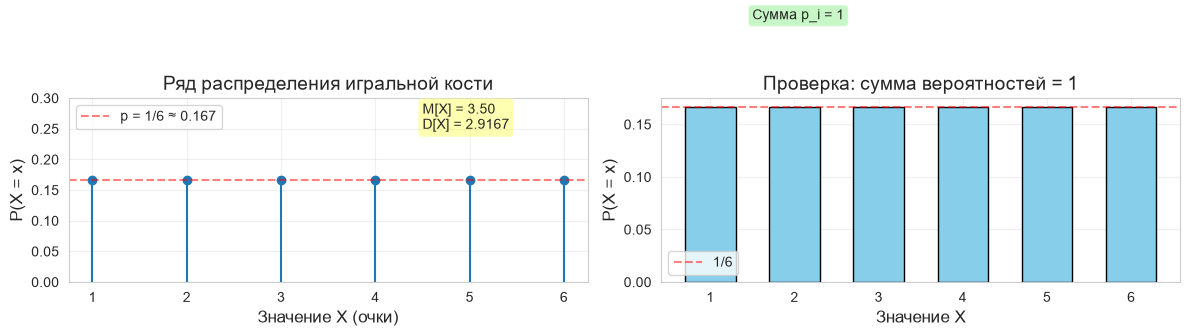

In [4]:
# Закон распределения для игральной кости (равномерное дискретное)
# Значения: X = {1, 2, 3, 4, 5, 6}, вероятности: p_i = 1/6

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.arange(1, 7)
p = np.full(6, 1/6)

# ---- РУЧНОЙ РАСЧЁТ M[X] и D[X] ----
# M[X] = sum(x_i * p_i) = (1+2+3+4+5+6)/6 = 21/6 = 3.5
M_X = np.sum(x * p)
print(f"Ручной расчёт M[X] = {M_X}")

# M[X^2] = sum(x_i^2 * p_i) = (1+4+9+16+25+36)/6 = 91/6 ≈ 15.1667
M_X2 = np.sum(x**2 * p)
print(f"Ручной расчёт M[X^2] = {M_X2:.4f}")

# D[X] = M[X^2] - (M[X])^2 = 91/6 - (21/6)^2 = 91/6 - 441/36 = 546/36 - 441/36 = 105/36 = 35/12 ≈ 2.9167
D_X = M_X2 - M_X**2
print(f"Ручной расчёт D[X] = {D_X:.4f}")
print(f"СКО = {np.sqrt(D_X):.4f}")

# ---- ГРАФИК ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График 1: Ряд распределения (полигон)
ax1.stem(x, p, basefmt=" ")
ax1.set_title('Ряд распределения игральной кости', fontsize=14)
ax1.set_xlabel('Значение X (очки)', fontsize=12)
ax1.set_ylabel('P(X = x)', fontsize=12)
ax1.set_ylim(0, 0.3)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1/6, color='red', linestyle='--', alpha=0.5, label=f'p = 1/6 ≈ {1/6:.3f}')
ax1.legend()
ax1.text(4.5, 0.25, f'M[X] = {M_X:.2f}\nD[X] = {D_X:.4f}',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3))

# График 2: Проверка нормировки
ax2.bar(x, p, width=0.6, color='skyblue', edgecolor='black')
ax2.axhline(y=1/6, color='red', linestyle='--', alpha=0.5, label='1/6')
ax2.set_title('Проверка: сумма вероятностей = 1', fontsize=14)
ax2.set_xlabel('Значение X', fontsize=12)
ax2.set_ylabel('P(X = x)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.text(1.5, 0.25, f'Сумма p_i = {sum(p):.0f}',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.5))
ax2.legend()

plt.tight_layout()
plt.show()

<a id="cdf-theory"></a>

⬅ [Предыдущая тема](#dsv-theory) | ➡ [Следующая тема](#csv-theory) | 📚 [К содержанию](#) | 📝 [Перейти к практическим задачам](#all-tasks)

---
# 📈 Функция распределения для дискретных случайных величин

## 📖 Определение

**Функция распределения** (кумулятивная функция) $F(x)$ показывает вероятность того, что случайная величина примет значение **меньше** $x$:

$$F(x) = P(X < x)$$

В Python и большинстве учебников используют **нестрогое неравенство**:
$$F(x) = P(X \le x)$$

Мы будем использовать вариант **$\le$**, так как он совпадает с реализацией в `scipy.stats`.

---
## 📐 Как строится F(x) для ДСВ

Для дискретной случайной величины $F(x)$ — это **ступенчатая функция**:
- На каждом интервале $(x_{i-1}, x_i]$ она постоянна.
- В точках $x_i$ происходит **скачок** вверх на величину $p_i = P(X = x_i)$.
- Левее первого значения $F(x) = 0$; правее последнего $F(x) = 1$.

---
## 🎲 Пример: игральная кость

**Ряд распределения:**

| $x_i$ | 1 | 2 | 3 | 4 | 5 | 6 |
|-------|---|---|---|---|---|---|
| $p_i$ | 1/6 | 1/6 | 1/6 | 1/6 | 1/6 | 1/6 |

**Функция распределения (с использованием $\le$):**

$$F(x) = \begin{cases}
0, & x < 1 \\
\frac{1}{6}, & 1 \le x < 2 \\
\frac{2}{6}, & 2 \le x < 3 \\
\frac{3}{6}, & 3 \le x < 4 \\
\frac{4}{6}, & 4 \le x < 5 \\
\frac{5}{6}, & 5 \le x < 6 \\
1, & x \ge 6
\end{cases}$$

**График:** ступеньки, каждая следующая выше предыдущей на $1/6$.

---
## 🔑 Ключевые формулы через F(x)

1. **Вероятность попадания в интервал:**
   $$P(a < X \le b) = F(b) - F(a)$$

2. **Вероятность конкретного значения:**
   $$P(X = x_i) = F(x_i) - F(x_{i-1})$$
   где $x_{i-1}$ — предыдущее значение перед $x_i$.

3. **Вероятность больше некоторого значения:**
   $$P(X > x) = 1 - F(x)$$

4. **Вероятность меньше некоторого значения:**
   ```math
   P(X < x) = F(x{})
   ```
   (предел слева, если используется $\le$)


---
## 📊 Свойства функции распределения

| Свойство | Описание |
|----------|----------|
| $0 \le F(x) \le 1$ | Вероятность всегда от 0 до 1 |
| $\lim_{x \to -\infty} F(x) = 0$ | Левее минимального значения — 0 |
| $\lim_{x \to +\infty} F(x) = 1$ | Правее максимального значения — 1 |
| Неубывающая | Если $x_1 < x_2$, то $F(x_1) \le F(x_2)$ |
| Непрерывна справа | $\lim_{x \to x_0+} F(x) = F(x_0)$ (при использовании $\le$) |
| Скачки | В точках $x_i$ возможны разрывы (скачки) |

---
## 🔗 Связь между рядом распределения и F(x)

$$\text{Ряд распределения} \xrightarrow{\text{суммирование}} F(x)$$
$$F(x) \xrightarrow{\text{разность скачков}} \text{Ряд распределения}$$

То есть они взаимно однозначно определяют друг друга.

---
⬆ [К содержанию](#) | 📝 [Все задачи по функции распределения](#all-tasks)
⬅ [Предыдущая тема](#dsv-theory) | ➡ [Следующая тема](#csv-theory)

F(x) = [0.16666667 0.33333333 0.5        0.66666667 0.83333333 1.        ]
P(2 <= X <= 5) = 0.6667
P(X = 3) = 0.1667


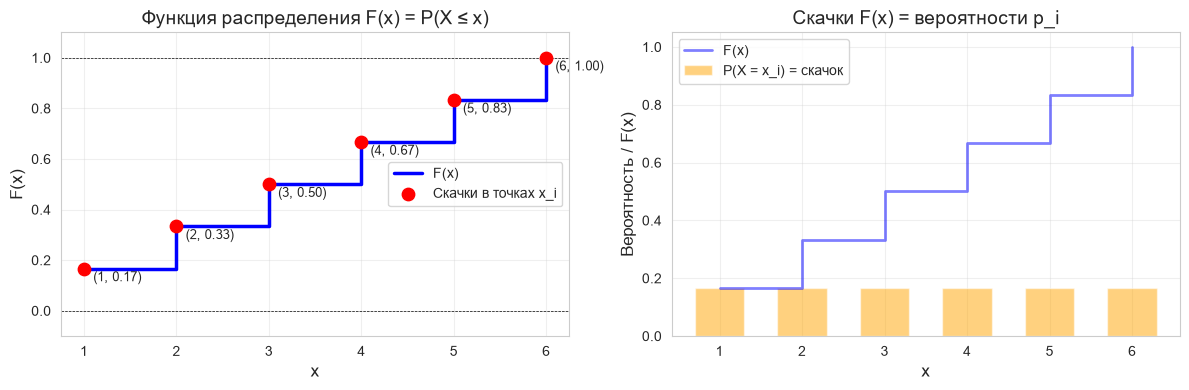

In [5]:
# Функция распределения для игральной кости F(x) = P(X <= x)

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, 7)
p = np.full(6, 1/6)

# Кумулятивная сумма (F(x) = P(X <= x))
F = np.cumsum(p)

# ---- РУЧНОЙ РАСЧЁТ через F(x) ----
# P(2 <= X <= 5) = F(5) - F(1) = 5/6 - 1/6 = 4/6 = 2/3 ≈ 0.6667
# P(X = 3) = F(3) - F(2) = 3/6 - 2/6 = 1/6

print(f"F(x) = {F}")
print(f"P(2 <= X <= 5) = {F[4] - F[0]:.4f}")  # индексы: 5-й элемент - 1-й
print(f"P(X = 3) = {F[2] - F[1]:.4f}")

# ---- ГРАФИК ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График 1: Функция распределения (ступенчатая)
ax1.step(x, F, where='post', linewidth=2.5, color='blue', label='F(x)')
ax1.scatter(x, F, color='red', zorder=5, s=80, label='Скачки в точках x_i')
# Добавляем горизонтальные линии для наглядности
ax1.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax1.axhline(y=1, color='black', linewidth=0.5, linestyle='--')
ax1.set_title('Функция распределения F(x) = P(X ≤ x)', fontsize=14)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('F(x)', fontsize=12)
ax1.set_ylim(-0.1, 1.1)
ax1.grid(True, alpha=0.3)
ax1.legend()
# Аннотация скачков
for i, (xi, fi) in enumerate(zip(x, F)):
    ax1.annotate(f'({xi}, {fi:.2f})', (xi, fi), xytext=(xi+0.1, fi-0.05), fontsize=9)

# График 2: Вероятности через скачки F
scales = np.diff(np.concatenate([[0], F]))  # Высота скачков
ax2.step(x, F, where='post', linewidth=2, color='blue', alpha=0.5, label='F(x)')
ax2.bar(x, scales, width=0.6, color='orange', alpha=0.5, label='P(X = x_i) = скачок')
ax2.set_title('Скачки F(x) = вероятности p_i', fontsize=14)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('Вероятность / F(x)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

<a id="csv-theory"></a>

⬅ [Предыдущая тема](#cdf-theory) | ➡ [Следующая тема](#binom-theory) | 📚 [К содержанию](#) | 📝 [Перейти к практическим задачам](#all-tasks)

---
# 🔢 Непрерывные случайные величины (НСВ)

## 📖 Определение

**Непрерывная случайная величина** — случайная величина, которая может принимать **любое значение** из некоторого интервала (конечного или бесконечного).

**Ключевое отличие от дискретной:**
- Для ДСВ $P(X = x_i) > 0$ для конкретных значений.
- Для НСВ $P(X = x) = 0$ **для любого конкретного $x$**!

Вероятность равна площади под графиком плотности, а так как площадь одной точки равна нулю, то и вероятность отдельного значения равна нулю.

**Примеры:**
- Рост человека (может быть 175.3 см, 175.31 см и т.д.).
- Время ожидания автобуса.
- Температура воздуха.
- Ошибка измерения.

---
## 📊 Плотность распределения $f(x)$

**Определение:**
$$f(x) = \lim_{\Delta x \to 0} \frac{P(x \le X \le x + \Delta x)}{\Delta x}$$

То есть плотность — это "скорость" накопления вероятности в точке $x$.

**Свойства плотности:**

| Свойство | Формула | Смысл |
|----------|---------|-------|
| Неотрицательность | $f(x) \ge 0$ | Вероятность не может быть отрицательной |
| Условие нормировки | $\int_{-\infty}^{\infty} f(x) dx = 1$ | Площадь под кривой = 1 (полная вероятность) |
| Вероятность попадания в интервал | $P(a < X < b) = \int_a^b f(x) dx$ | Площадь под кривой на интервале |
| Связь с F(x) | $f(x) = F'(x)$ | Плотность — производная функции распределения |

---
## 📈 Функция распределения $F(x)$ для НСВ

**Определение:**
$$F(x) = P(X \le x) = \int_{-\infty}^{x} f(t) dt$$

**Свойства:**

| Свойство | Описание |
|----------|----------|
| $0 \le F(x) \le 1$ | Вероятность всегда от 0 до 1 |
| $\lim_{x \to -\infty} F(x) = 0$ | Левее минимального значения — 0 |
| $\lim_{x \to +\infty} F(x) = 1$ | Правее максимального значения — 1 |
| **Неубывающая** | Если $x_1 < x_2$, то $F(x_1) \le F(x_2)$ |
| **Непрерывная** (без скачков!) | В отличие от ДСВ, у НСВ нет скачков |
| $P(a < X < b) = F(b) - F(a)$ | Вероятность через функцию распределения |

---
## ⚖️ Сравнение ДСВ и НСВ

| Характеристика | Дискретная СВ | Непрерывная СВ |
|----------------|---------------|----------------|
| Множество значений | Конечное или счётное | Непрерывный интервал |
| $P(X = x)$ | Может быть > 0 | **Всегда 0** |
| Закон распределения | Ряд распределения $p_i$ | Плотность $f(x)$ |
| Функция распределения | Ступенчатая | Непрерывная (гладкая) |
| Связь $F$ и закона | $F(x) = \sum_{x_i \le x} p_i$ | $F(x) = \int_{-\infty}^{x} f(t) dt$ |
| Обратная связь | $p_i = F(x_i) - F(x_{i-1})$ | $f(x) = F'(x)$ |

---
## 🔢 Числовые характеристики для НСВ

### Математическое ожидание
$$M[X] = \int_{-\infty}^{\infty} x \cdot f(x) dx$$

### Дисперсия
$$D[X] = \int_{-\infty}^{\infty} (x - M[X])^2 \cdot f(x) dx = M[X^2] - (M[X])^2$$

### Квантили

**Квантиль порядка $q$** — это значение $x_q$, такое что:
$$F(x_q) = q$$
То есть $x_q = F^{-1}(q)$ (обратная функция распределения).

**Примеры:**
- Медиана: $x_{0.5}$ (50% значений слева)
- Квартили: $x_{0.25}$ и $x_{0.75}$

### Мода

Значение $x$, при котором $f(x)$ максимальна (пик плотности).

---
⬆ [К содержанию](#) | 📝 [Все задачи по НСВ](#all-tasks)
⬅ [Предыдущая тема](#cdf-theory) | ➡ [Следующая тема](#binom-theory)

Теоретическое M[X] = 0
Теоретическое D[X] = 1
Численное интегрирование M[X] = 0.0000
Численное интегрирование D[X] = 1.0000


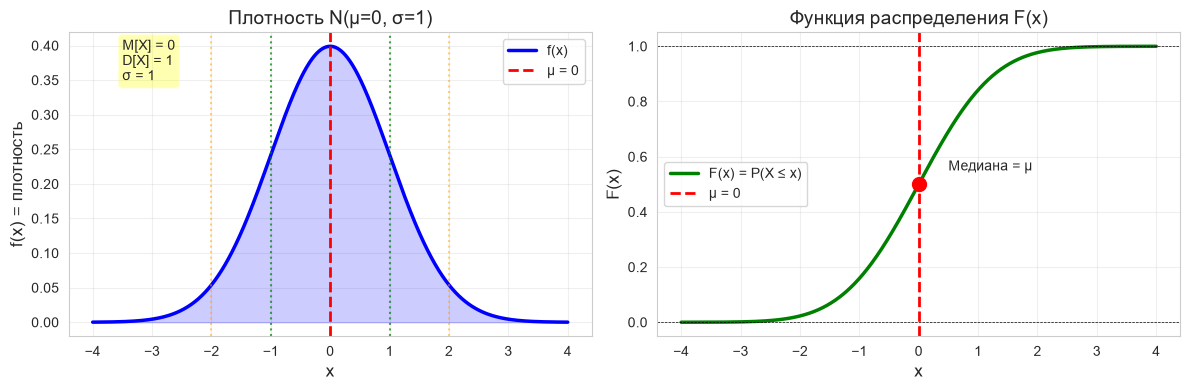

In [6]:
# Нормальное распределение N(μ, σ²) — расчёт M[X] и D[X] аналитически
# Плотность: f(x) = (1/(σ√(2π))) * exp(-(x-μ)²/(2σ²))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad

mu, sigma = 0, 1
x_cont = np.linspace(-4, 4, 1000)

# ---- АНАЛИТИЧЕСКИЙ РАСЧЁТ (теория) ----
# M[X] = ∫ x*f(x) dx = μ (доказывается через замену t = (x-μ)/σ)
# D[X] = ∫ (x-μ)²*f(x) dx = σ²
print(f"Теоретическое M[X] = {mu}")
print(f"Теоретическое D[X] = {sigma**2}")

# ---- ЧИСЛЕННАЯ ПРОВЕРКА через интегралы ----
def pdf_norm(x):
    return stats.norm.pdf(x, mu, sigma)

# Численное интегрирование для проверки
M_num, _ = quad(lambda x: x * pdf_norm(x), -10, 10)
D_num, _ = quad(lambda x: (x - mu)**2 * pdf_norm(x), -10, 10)
print(f"Численное интегрирование M[X] = {M_num:.4f}")
print(f"Численное интегрирование D[X] = {D_num:.4f}")

# ---- ГРАФИК 1: Плотность с аннотациями ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

pdf = stats.norm.pdf(x_cont, mu, sigma)
cdf = stats.norm.cdf(x_cont, mu, sigma)

ax1.plot(x_cont, pdf, color='blue', linewidth=2.5, label='f(x)')
ax1.fill_between(x_cont, pdf, alpha=0.2, color='blue')
ax1.axvline(x=mu, color='red', linestyle='--', linewidth=2, label=f'μ = {mu}')
# Правило 3-х сигм
ax1.axvline(x=mu - sigma, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
ax1.axvline(x=mu + sigma, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
ax1.axvline(x=mu - 2*sigma, color='orange', linestyle=':', linewidth=1.5, alpha=0.5)
ax1.axvline(x=mu + 2*sigma, color='orange', linestyle=':', linewidth=1.5, alpha=0.5)
ax1.set_title(f'Плотность N(μ={mu}, σ={sigma})', fontsize=14)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x) = плотность', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.text(-3.5, 0.35, f'M[X] = {mu}\nD[X] = {sigma**2}\nσ = {sigma}',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3))

# ---- ГРАФИК 2: Функция распределения ----
ax2.plot(x_cont, cdf, color='green', linewidth=2.5, label='F(x) = P(X ≤ x)')
ax2.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax2.axhline(y=1, color='black', linewidth=0.5, linestyle='--')
ax2.axvline(x=mu, color='red', linestyle='--', linewidth=2, label=f'μ = {mu}')
# Медиана: F(μ) = 0.5
ax2.scatter(mu, 0.5, color='red', s=100, zorder=5)
ax2.annotate('Медиана = μ', (mu, 0.5), xytext=(mu+0.5, 0.55), fontsize=10)
ax2.set_title('Функция распределения F(x)', fontsize=14)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('F(x)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

<a id="binom-theory"></a>

⬅ [Предыдущая тема](#csv-theory) | ➡ [Следующая тема](#geom-theory) | 📚 [К содержанию](#) | 📝 [Перейти к практическим задачам](#all-tasks)

---
# 🎲 Биномиальное распределение: $X \sim \text{Bin}(n, p)$

## 📖 Определение

Описывает **количество успехов** в серии из $n$ независимых испытаний, в каждом из которых вероятность успеха равна $p$ (схема Бернулли).

**Примеры из жизни:**
- Сколько раз выпадет "орел" при 10 подбрасываниях монеты.
- Сколько бракованных деталей в партии из 50 (если вероятность брака 2%).
- Сколько пациентов вылечится из 100 при эффективности лекарства 80%.

---
## 📐 Закон распределения (формула Бернулли)

$$P(X = k) = C_n^k \cdot p^k \cdot (1-p)^{n-k}, \quad k = 0, 1, 2, ..., n$$

где:
- $C_n^k = \frac{n!}{k!(n-k)!}$ — число сочетаний (сколько способов выбрать $k$ успешных мест среди $n$),
- $p^k$ — вероятность, что $k$ испытаний закончатся успехом,
- $(1-p)^{n-k}$ — вероятность, что остальные $n-k$ испытаний закончатся неудачей.

**Проверка:** $\sum_{k=0}^{n} P(X=k) = (p + (1-p))^n = 1$ (бином Ньютона).

---
## 🔢 Числовые характеристики

| Характеристика | Формула |
|----------------|---------|
| Мат. ожидание  | $M[X] = n \cdot p$ |
| Дисперсия      | $D[X] = n \cdot p \cdot (1-p)$ |
| СКО            | $\sigma = \sqrt{n \cdot p \cdot (1-p)}$ |
| Коэффициент асимметрии | $\frac{1-2p}{\sqrt{n p (1-p)}}$ |
| Коэффициент эксцесса | $\frac{1-6p(1-p)}{n p (1-p)}$ |

---
## ✨ Свойства

1. **Аддитивность:** если $X \sim \text{Bin}(n_1, p)$ и $Y \sim \text{Bin}(n_2, p)$ независимы, то $X+Y \sim \text{Bin}(n_1+n_2, p)$.

2. **Предельные переходы:**
   - При $n \to \infty$ и $p \to 0$ так, что $n \cdot p = \lambda = \text{const}$, биномиальное распределение **сходится к распределению Пуассона** $\text{Poisson}(\lambda)$.
   - При $n \to \infty$ и фиксированном $p$ (не близком к 0 или 1), биномиальное распределение **сходится к нормальному** $N(np, np(1-p))$ (теорема Муавра-Лапласа).

3. **Мода** (наиболее вероятное значение $k$):
   - Если $(n+1)p$ — целое число, то мод две: $k = (n+1)p$ и $k = (n+1)p - 1$.
   - Иначе мода одна: $k = \lfloor (n+1)p \rfloor$.

---
## 📈 Функция распределения

$$F(x) = P(X \le x) = \sum_{k=0}^{\lfloor x \rfloor} C_n^k p^k (1-p)^{n-k}$$

Выражается через **неполную бета-функцию**, но в Python считается через `stats.binom.cdf()`.

---
## 📊 Графики при разных параметрах

- Если $p = 0.5$ — распределение **симметричное** (как колокол).
- Если $p < 0.5$ — скошено вправо (чаще мало успехов).
- Если $p > 0.5$ — скошено влево (чаще много успехов).
- Чем больше $n$, тем более гладким и похожим на нормальное оно становится.

---
⬆ [К содержанию](#) | 📝 [Все задачи по биномиальному распределению](#all-tasks)
⬅ [Предыдущая тема](#csv-theory) | ➡ [Следующая тема](#geom-theory)

Ручной расчёт через сумму: M[X] = 18.0000
Ручной расчёт через сумму: D[X] = 7.2000
Теоретические формулы: M[X] = 18.0, D[X] = 7.2


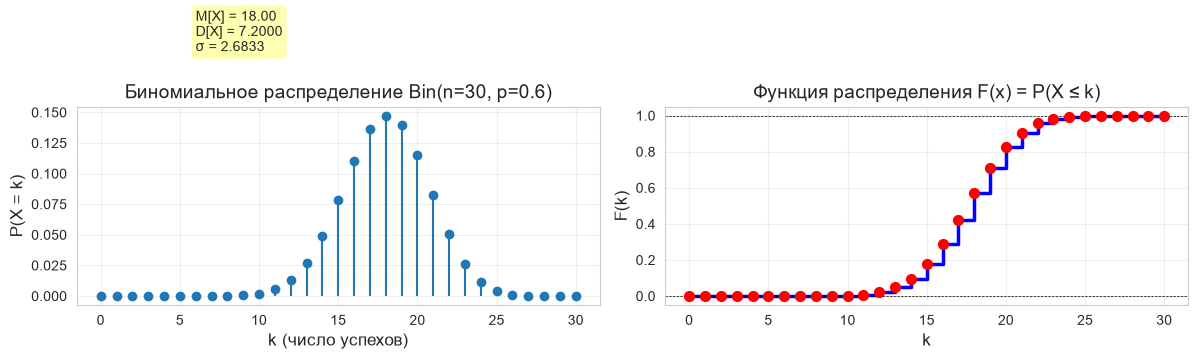

In [7]:
# Биномиальное распределение Bin(n, p)
# P(X = k) = C(n, k) * p^k * (1-p)^(n-k)
# M[X] = n*p, D[X] = n*p*(1-p)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import comb

n, p = 30, 0.6
k_values = np.arange(0, n+1)

# ---- РУЧНОЙ РАСЧЁТ через сумму ----
# M[X] = sum(k * P(X=k))
probs = stats.binom.pmf(k_values, n, p)
M_manual = np.sum(k_values * probs)
D_manual = np.sum((k_values - M_manual)**2 * probs)

print(f"Ручной расчёт через сумму: M[X] = {M_manual:.4f}")
print(f"Ручной расчёт через сумму: D[X] = {D_manual:.4f}")
print(f"Теоретические формулы: M[X] = {n*p}, D[X] = {n*p*(1-p)}")

# ---- ГРАФИК ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График 1: Ряд распределения
ax1.stem(k_values, probs, basefmt=" ")
ax1.set_title(f'Биномиальное распределение Bin(n={n}, p={p})', fontsize=14)
ax1.set_xlabel('k (число успехов)', fontsize=12)
ax1.set_ylabel('P(X = k)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.text(6, 0.2, f'M[X] = {M_manual:.2f}\nD[X] = {D_manual:.4f}\nσ = {np.sqrt(D_manual):.4f}',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3))

# График 2: Кумулятивная сумма (F(x))
F = np.cumsum(probs)
ax2.step(k_values, F, where='post', linewidth=2.5, color='blue')
ax2.scatter(k_values, F, color='red', zorder=5, s=50)
ax2.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax2.axhline(y=1, color='black', linewidth=0.5, linestyle='--')
ax2.set_title('Функция распределения F(x) = P(X ≤ k)', fontsize=14)
ax2.set_xlabel('k', fontsize=12)
ax2.set_ylabel('F(k)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id="geom-theory"></a>

⬅ [Предыдущая тема](#binom-theory) | ➡ [Следующая тема](#poisson-theory) | 📚 [К содержанию](#) | 📝 [Перейти к практическим задачам](#all-tasks)

---
# 🎯 Геометрическое распределение: $X \sim \text{Geom}(p)$

## 📖 Определение

Описывает **номер первого успешного испытания** в бесконечной последовательности независимых испытаний Бернулли с вероятностью успеха $p$.

**Примеры из жизни:**
- Сколько раз нужно бросить монету, чтобы впервые выпал "орел".
- Сколько звонков нужно сделать, чтобы дозвониться (если вероятность дозвона $p$).
- Сколько выстрелов потребуется снайперу для первого попадания.

---
## 📐 Закон распределения (счет от 1)

$$P(X = k) = (1-p)^{k-1} \cdot p, \quad k = 1, 2, 3, ...$$

**Логика:** первые $k-1$ раз — неудачи (вероятность $(1-p)^{k-1}$), на $k$-й раз — успех (вероятность $p$).

**Проверка:** $\sum_{k=1}^{\infty} P(X=k) = p \sum_{k=1}^{\infty} (1-p)^{k-1} = p \cdot \frac{1}{1-(1-p)} = 1$ (бесконечная геометрическая прогрессия).

> **Важно:** Существует альтернативная форма (счет от 0), где $P(X = k) = (1-p)^k \cdot p$ — это число неудач до первого успеха. В `scipy.stats.geom` используется **счет от 1**.

---
## 🔢 Числовые характеристики

| Характеристика | Формула |
|----------------|---------|
| Мат. ожидание  | $M[X] = \frac{1}{p}$ |
| Дисперсия      | $D[X] = \frac{1-p}{p^2}$ |
| СКО            | $\sigma = \frac{\sqrt{1-p}}{p}$ |
| Коэффициент асимметрии | $\frac{2-p}{\sqrt{1-p}}$ |
| Коэффициент эксцесса | $6 + \frac{p^2}{1-p}$ |

---
## ✨ Свойства

1. **Отсутствие памяти (марковское свойство):**
   $$P(X > s + t \mid X > s) = P(X > t)$$
   **Смысл:** если вы уже ждали $s$ раз и не дождались успеха, то вероятность ждать еще $t$ раз такая же, как если бы вы начинали сначала. Распределение "не стареет".

2. **Связь с экспоненциальным распределением:**
   - Дискретный аналог экспоненциального распределения.
   - Если $Y \sim \text{Exp}(\lambda)$, то $X = \lfloor Y \rfloor$ имеет геометрическое распределение с $p = 1 - e^{-\lambda}$.

3. **Минимальное из геометрических:**
   Если $X_1, X_2, ..., X_n$ независимы и $X_i \sim \text{Geom}(p_i)$, то $\min(X_1, ..., X_n) \sim \text{Geom}\left(1 - \prod_{i=1}^n (1-p_i)\right)$.

---
## 📈 Функция распределения

$$F(x) = P(X \le x) = 1 - (1-p)^{\lfloor x \rfloor}, \quad x \ge 1$$

**Квантиль:** $x_{0.5} = \left\lceil \frac{\ln(1-0.5)}{\ln(1-p)} \right\rceil$ (медиана).

---
## 📊 Графики при разных $p$

- Чем меньше $p$, тем медленнее убывают вероятности — "длинный хвост".
- Чем больше $p$ (ближе к 1), тем быстрее вероятность падает — почти всегда успех наступает сразу.
- При $p = 0.5$ — наиболее "размазанный" случай (среднее = 2).

---
⬆ [К содержанию](#) | 📝 [Все задачи по геометрическому распределению](#all-tasks)
⬅ [Предыдущая тема](#binom-theory) | ➡ [Следующая тема](#poisson-theory)

Теоретическое M[X] = 1/p = 10.0000
Теоретическое D[X] = (1-p)/p² = 90.0000
Приближение по первым 20 членам: M ≈ 8.3044, D ≈ 46.4733


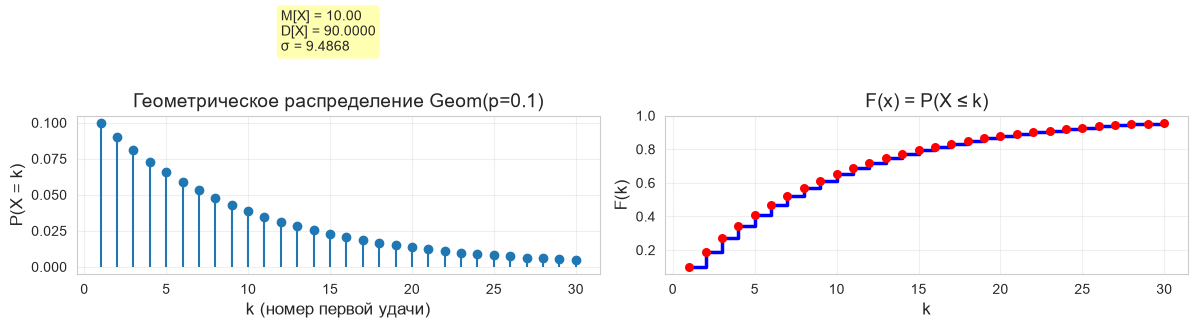

In [8]:
# Геометрическое распределение Geom(p) (счет от 1)
# P(X = k) = (1-p)^(k-1) * p, k = 1,2,3,...
# M[X] = 1/p, D[X] = (1-p)/p^2

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

p_geom = 0.1
k_geom = np.arange(1, 31)

probs_geom = stats.geom.pmf(k_geom, p_geom)

# ---- РУЧНОЙ РАСЧЁТ через сумму (по конечному числу) ----
# Для бесконечного ряда используем формулы
M_theory = 1/p_geom
D_theory = (1-p_geom)/p_geom**2

print(f"Теоретическое M[X] = 1/p = {M_theory:.4f}")
print(f"Теоретическое D[X] = (1-p)/p² = {D_theory:.4f}")

# Проверка на конечной выборке (приближённо)
M_approx = np.sum(k_geom * probs_geom)
D_approx = np.sum((k_geom - M_approx)**2 * probs_geom)
print(f"Приближение по первым 20 членам: M ≈ {M_approx:.4f}, D ≈ {D_approx:.4f}")

# ---- ГРАФИК ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График 1: Ряд распределения
ax1.stem(k_geom, probs_geom, basefmt=" ")
ax1.set_title(f'Геометрическое распределение Geom(p={p_geom})', fontsize=14)
ax1.set_xlabel('k (номер первой удачи)', fontsize=12)
ax1.set_ylabel('P(X = k)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.text(12, 0.15, f'M[X] = {M_theory:.2f}\nD[X] = {D_theory:.4f}\nσ = {np.sqrt(D_theory):.4f}',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3))

# График 2: Кумулятивная сумма
F_geom = np.cumsum(probs_geom)
ax2.step(k_geom, F_geom, where='post', linewidth=2.5, color='blue')
ax2.scatter(k_geom, F_geom, color='red', zorder=5, s=30)
ax2.axhline(y=1, color='black', linewidth=0.5, linestyle='--')
ax2.set_title('F(x) = P(X ≤ k)', fontsize=14)
ax2.set_xlabel('k', fontsize=12)
ax2.set_ylabel('F(k)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id="poisson-theory"></a>

⬅ [Предыдущая тема](#geom-theory) | ➡ [Следующая тема](#unif-theory) | 📚 [К содержанию](#) | 📝 [Перейти к практическим задачам](#all-tasks)

---
# 📞 Распределение Пуассона: $X \sim \text{Poisson}(\lambda)$

## 📖 Определение

Описывает **количество событий**, происходящих за фиксированный промежуток времени/пространства, если события происходят случайно, независимо и с постоянной средней интенсивностью $\lambda$.

**Примеры из жизни:**
- Количество звонков в колл-центр за час.
- Количество автомобилей, проезжающих перекресток за минуту.
- Количество опечаток на странице книги.
- Количество мутаций в участке ДНК.

---
## 📐 Закон распределения

$$P(X = k) = \frac{\lambda^k \cdot e^{-\lambda}}{k!}, \quad k = 0, 1, 2, 3, ...$$

**Проверка:** $\sum_{k=0}^{\infty} P(X=k) = e^{-\lambda} \sum_{k=0}^{\infty} \frac{\lambda^k}{k!} = e^{-\lambda} \cdot e^{\lambda} = 1$ (разложение экспоненты в ряд).

---
## 🔢 Числовые характеристики

| Характеристика | Формула |
|----------------|---------|
| Мат. ожидание  | $M[X] = \lambda$ |
| Дисперсия      | $D[X] = \lambda$ |
| СКО            | $\sigma = \sqrt{\lambda}$ |
| Коэффициент асимметрии | $\frac{1}{\sqrt{\lambda}}$ |
| Коэффициент эксцесса | $\frac{1}{\lambda}$ |

> **Удивительный факт:** для распределения Пуассона $M[X] = D[X]$! Это ключевой признак, по которому его можно идентифицировать на практике.

---
## ✨ Свойства

1. **Аддитивность (сумма Пуассонов):**
   Если $X \sim \text{Poisson}(\lambda_1)$ и $Y \sim \text{Poisson}(\lambda_2)$ независимы, то
   $$X + Y \sim \text{Poisson}(\lambda_1 + \lambda_2)$$

2. **Предельный случай биномиального (закон редких событий):**
   Если $X_n \sim \text{Bin}(n, p_n)$ и $n \to \infty$, $p_n \to 0$, $n \cdot p_n = \lambda = \text{const}$, то
   $$\lim_{n \to \infty} P(X_n = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$
   **То есть** Пуассон — это биномиальное для редких событий при большом $n$.

3. **Связь с экспоненциальным распределением:**
   - Время между событиями в пуассоновском потоке имеет экспоненциальное распределение.
   - Количество событий за время $t$ имеет распределение $\text{Poisson}(\lambda t)$.

4. **Условное распределение:**
   Если $X \sim \text{Poisson}(\lambda_1)$, $Y \sim \text{Poisson}(\lambda_2)$ независимы, то
   $$P(X = k \mid X+Y = n) = C_n^k \cdot \left(\frac{\lambda_1}{\lambda_1+\lambda_2}\right)^k \cdot \left(\frac{\lambda_2}{\lambda_1+\lambda_2}\right)^{n-k}$$
   То есть **биномиальное** распределение!

---
## 📈 Функция распределения

$$F(x) = P(X \le x) = e^{-\lambda} \sum_{k=0}^{\lfloor x \rfloor} \frac{\lambda^k}{k!}$$

Выражается через **неполную гамма-функцию**: $F(x) = \frac{\Gamma(\lfloor x \rfloor + 1, \lambda)}{\lfloor x \rfloor!}$.

---
## 📊 Графики при разных $\lambda$

- $\lambda < 1$ — быстро убывает, максимум в 0.
- $\lambda = 1$ — плавный спад.
- $\lambda > 1$ — распределение становится похожим на нормальное (смещается вправо, становится симметричнее).
- При $\lambda \to \infty$ Пуассон сходится к $N(\lambda, \lambda)$.

---
⬆ [К содержанию](#) | 📝 [Все задачи по распределению Пуассона](#all-tasks)
⬅ [Предыдущая тема](#geom-theory) | ➡ [Следующая тема](#unif-theory)

Ручной расчёт: M[X] = 5.0000
Ручной расчёт: D[X] = 5.0000
Теоретические: M[X] = λ = 5, D[X] = λ = 5


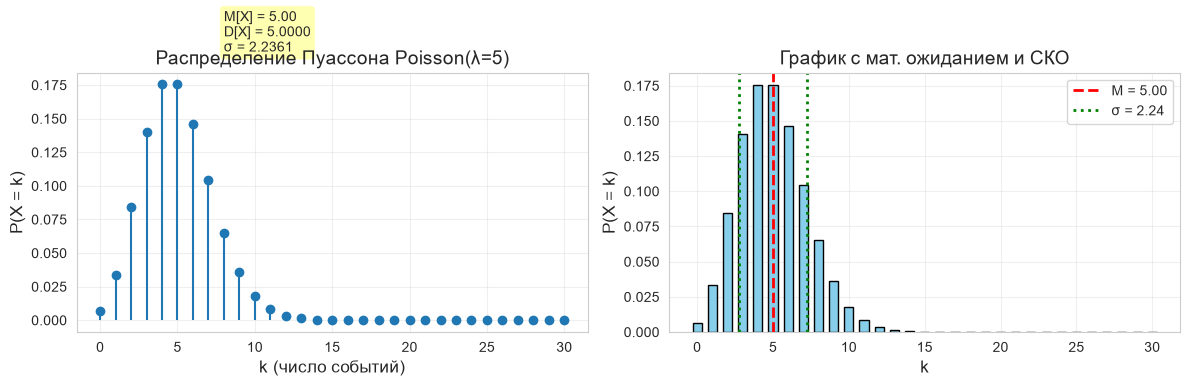

In [9]:
# Распределение Пуассона Poisson(λ)
# P(X = k) = (λ^k * e^(-λ)) / k!, k = 0,1,2,...
# M[X] = λ, D[X] = λ

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

lam = 5
k_pois = np.arange(0, 31)

probs_pois = stats.poisson.pmf(k_pois, lam)

# ---- РУЧНОЙ РАСЧЁТ через сумму ----
M_pois = np.sum(k_pois * probs_pois)
D_pois = np.sum((k_pois - M_pois)**2 * probs_pois)

print(f"Ручной расчёт: M[X] = {M_pois:.4f}")
print(f"Ручной расчёт: D[X] = {D_pois:.4f}")
print(f"Теоретические: M[X] = λ = {lam}, D[X] = λ = {lam}")

# ---- ГРАФИК ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График 1: Ряд распределения
ax1.stem(k_pois, probs_pois, basefmt=" ")
ax1.set_title(f'Распределение Пуассона Poisson(λ={lam})', fontsize=14)
ax1.set_xlabel('k (число событий)', fontsize=12)
ax1.set_ylabel('P(X = k)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.text(8, 0.2, f'M[X] = {M_pois:.2f}\nD[X] = {D_pois:.4f}\nσ = {np.sqrt(D_pois):.4f}',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3))

# График 2: Проверка свойства M[X] = D[X] = λ
ax2.bar(k_pois, probs_pois, width=0.6, color='skyblue', edgecolor='black')
ax2.axvline(x=M_pois, color='red', linestyle='--', linewidth=2, label=f'M = {M_pois:.2f}')
ax2.axvline(x=M_pois + np.sqrt(D_pois), color='green', linestyle=':', linewidth=2, label=f'σ = {np.sqrt(D_pois):.2f}')
ax2.axvline(x=M_pois - np.sqrt(D_pois), color='green', linestyle=':', linewidth=2)
ax2.set_title('График с мат. ожиданием и СКО', fontsize=14)
ax2.set_xlabel('k', fontsize=12)
ax2.set_ylabel('P(X = k)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

<a id="unif-theory"></a>

⬅ [Предыдущая тема](#poisson-theory) | ➡ [Следующая тема](#exp-theory) | 📚 [К содержанию](#) | 📝 [Перейти к практическим задачам](#all-tasks)

---
# 📏 Непрерывное равномерное распределение: $X \sim U(a, b)$

## 📖 Определение

Все значения на отрезке $[a, b]$ **равновероятны**. Это самое простое непрерывное распределение.

**Примеры из жизни:**
- Время прибытия автобуса, который ходит строго по расписанию (если вы не знаете расписание).
- Ошибка округления при измерении.
- Координата точки, брошенной наудачу на отрезок.
- Генерация случайного числа в компьютере (стандартный генератор возвращает $U(0, 1)$).

---
## 📐 Плотность распределения

$$f(x) = \begin{cases} \frac{1}{b-a}, & a \le x \le b \\ 0, & \text{иначе} \end{cases}$$

**Проверка:** $\int_{-\infty}^{\infty} f(x) dx = \int_a^b \frac{1}{b-a} dx = 1$.

---
## 📈 Функция распределения

$$F(x) = \begin{cases} 0, & x < a \\ \frac{x-a}{b-a}, & a \le x \le b \\ 1, & x > b \end{cases}$$

---
## 🔢 Числовые характеристики

| Характеристика | Формула |
|----------------|---------|
| Мат. ожидание  | $M[X] = \frac{a+b}{2}$ |
| Дисперсия      | $D[X] = \frac{(b-a)^2}{12}$ |
| СКО            | $\sigma = \frac{b-a}{2\sqrt{3}}$ |
| Коэффициент асимметрии | $0$ (симметричное) |
| Коэффициент эксцесса | $-1.2$ (более плоское, чем нормальное) |
| Медиана | $\frac{a+b}{2}$ |
| Квантиль порядка $q$ | $a + q \cdot (b-a)$ |

---
## ✨ Свойства

1. **Инвариантность относительно линейного преобразования:**
   Если $X \sim U(a, b)$, то $Y = c \cdot X + d \sim U(ca + d, cb + d)$.

2. **Стандартное равномерное распределение:** $U(0, 1)$.
   - Именно его генерирует `np.random.uniform(0, 1)`.
   - Любое другое равномерное получается как $X = a + (b-a) \cdot U(0, 1)$.

3. **Связь с другими распределениями (метод обратной функции):**
   Если $U \sim U(0, 1)$, то:
   - $X = -\frac{1}{\lambda} \ln(1-U) \sim \text{Exp}(\lambda)$ (экспоненциальное).
   - $X = \mu + \sigma \cdot \Phi^{-1}(U) \sim N(\mu, \sigma^2)$ (нормальное через обратную функцию).
   - Это основа для генерации любых случайных величин в компьютере.

4. **Порядковые статистики:**
   Если $X_1, ..., X_n \sim U(0, 1)$ независимы, то $X_{(k)}$ (k-я порядковая статистика) имеет бета-распределение $\text{Beta}(k, n-k+1)$.

---
## 📊 Графики

- Плотность — прямоугольник (отсюда название).
- При изменении $a$ и $b$ график просто сдвигается и меняет высоту (площадь всегда 1).
- Чем шире отрезок, тем ниже плотность.

---
⬆ [К содержанию](#) | 📝 [Все задачи по равномерному распределению](#all-tasks)
⬅ [Предыдущая тема](#poisson-theory) | ➡ [Следующая тема](#exp-theory)

Теоретическое M[X] = (a+b)/2 = 5.0
Теоретическое D[X] = (b-a)²/12 = 8.3333
Численное интегрирование: M[X] = 5.0000, D[X] = 8.3333


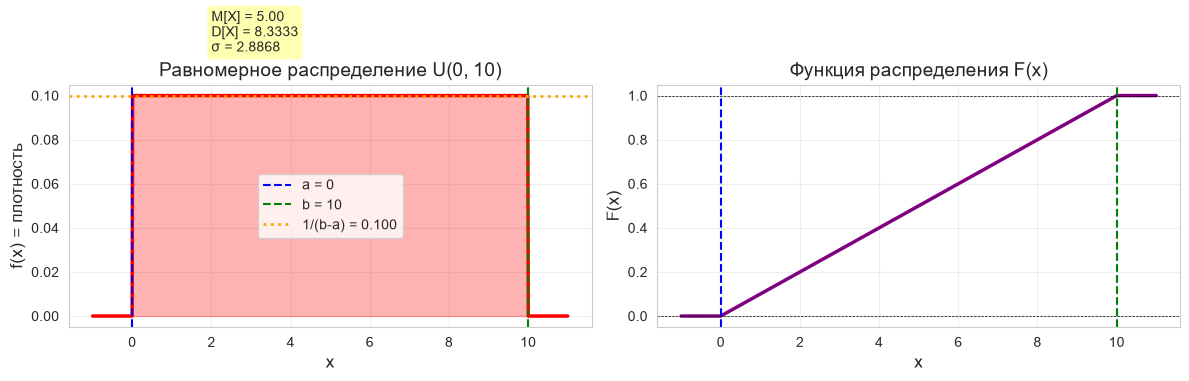

In [10]:
# Непрерывное равномерное распределение U(a, b)
# f(x) = 1/(b-a), a ≤ x ≤ b
# M[X] = (a+b)/2, D[X] = (b-a)²/12

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad

a, b = 0, 10
x_unif = np.linspace(a-1, b+1, 1000)

# ---- АНАЛИТИЧЕСКИЙ РАСЧЁТ ----
M_theory = (a + b) / 2
D_theory = (b - a)**2 / 12

print(f"Теоретическое M[X] = (a+b)/2 = {M_theory}")
print(f"Теоретическое D[X] = (b-a)²/12 = {D_theory:.4f}")

# ---- ЧИСЛЕННАЯ ПРОВЕРКА через интегралы ----
def pdf_uniform(x):
    return stats.uniform.pdf(x, a, b-a)

M_num, _ = quad(lambda x: x * pdf_uniform(x), a-1, b+1)
D_num, _ = quad(lambda x: (x - M_num)**2 * pdf_uniform(x), a-1, b+1)
print(f"Численное интегрирование: M[X] = {M_num:.4f}, D[X] = {D_num:.4f}")

# ---- ГРАФИК ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

pdf_unif = stats.uniform.pdf(x_unif, a, b-a)
cdf_unif = stats.uniform.cdf(x_unif, a, b-a)

# График 1: Плотность
ax1.plot(x_unif, pdf_unif, color='red', linewidth=2.5)
ax1.fill_between(x_unif, pdf_unif, alpha=0.3, color='red')
ax1.axvline(x=a, color='blue', linestyle='--', linewidth=1.5, label=f'a = {a}')
ax1.axvline(x=b, color='green', linestyle='--', linewidth=1.5, label=f'b = {b}')
ax1.axhline(y=1/(b-a), color='orange', linestyle=':', linewidth=2, label=f'1/(b-a) = {1/(b-a):.3f}')
ax1.set_title(f'Равномерное распределение U({a}, {b})', fontsize=14)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x) = плотность', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.text(2, 0.12, f'M[X] = {M_theory:.2f}\nD[X] = {D_theory:.4f}\nσ = {np.sqrt(D_theory):.4f}',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3))

# График 2: Функция распределения
ax2.plot(x_unif, cdf_unif, color='purple', linewidth=2.5)
ax2.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax2.axhline(y=1, color='black', linewidth=0.5, linestyle='--')
ax2.axvline(x=a, color='blue', linestyle='--', linewidth=1.5)
ax2.axvline(x=b, color='green', linestyle='--', linewidth=1.5)
ax2.set_title('Функция распределения F(x)', fontsize=14)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('F(x)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id="exp-theory"></a>

⬅ [Предыдущая тема](#unif-theory) | ➡ [Следующая тема](#norm-theory) | 📚 [К содержанию](#) | 📝 [Перейти к практическим задачам](#all-tasks)

---
# ⏳ Экспоненциальное (показательное) распределение: $X \sim \text{Exp}(\lambda)$

## 📖 Определение

Описывает **время между событиями** в пуассоновском потоке событий с интенсивностью $\lambda$ (среднее число событий за единицу времени).

**Примеры из жизни:**
- Время ожидания следующего звонка в колл-центре.
- Время жизни радиоактивного атома.
- Время безотказной работы электронного компонента (при постоянной интенсивности отказов).
- Расстояние между соседними автомобилями на трассе.

---
## 📐 Плотность распределения

$$f(x) = \begin{cases} \lambda \cdot e^{-\lambda x}, & x \ge 0 \\ 0, & x < 0 \end{cases}$$

**Проверка:** $\int_0^{\infty} \lambda e^{-\lambda x} dx = [-e^{-\lambda x}]_0^{\infty} = 1$.

---
## 📈 Функция распределения

$$F(x) = \begin{cases} 1 - e^{-\lambda x}, & x \ge 0 \\ 0, & x < 0 \end{cases}$$

---
## 🔢 Числовые характеристики

| Характеристика | Формула |
|----------------|---------|
| Мат. ожидание  | $M[X] = \frac{1}{\lambda}$ |
| Дисперсия      | $D[X] = \frac{1}{\lambda^2}$ |
| СКО            | $\sigma = \frac{1}{\lambda}$ |
| Коэффициент асимметрии | $2$ (сильная правосторонняя асимметрия) |
| Коэффициент эксцесса | $6$ (вытянутый хвост) |
| Медиана        | $\frac{\ln 2}{\lambda}$ |

---
## ✨ Свойства

1. **Отсутствие памяти (марковское свойство):**
   $$P(X > s+t \mid X > s) = P(X > t), \quad \forall s, t \ge 0$$

   **Смысл:** Если вы ждали автобус уже $s$ минут, вероятность ждать еще $t$ минут такая же, как если бы вы только что пришли. Распределение "не стареет". Это **единственное** непрерывное распределение с этим свойством.

2. **Минимальное из экспоненциальных:**
   Если $X_1, ..., X_n$ независимы и $X_i \sim \text{Exp}(\lambda_i)$, то
   $$\min(X_1, ..., X_n) \sim \text{Exp}\left(\sum_{i=1}^n \lambda_i\right)$$
   **Смысл:** время до первого события из $n$ независимых источников — экспоненциальное с суммой интенсивностей.

3. **Связь с распределением Пуассона:**
   - $P(X > t) = P(\text{за время } t \text{ не произошло ни одного события}) = e^{-\lambda t}$.
   - Если количество событий за время $t$ ~ $\text{Poisson}(\lambda t)$, то время до первого события ~ $\text{Exp}(\lambda)$.

4. **Связь с гамма-распределением:**
   Сумма $n$ независимых $\text{Exp}(\lambda)$ имеет гамма-распределение $\text{Gamma}(n, 1/\lambda)$ (время до $n$-го события).

5. **Параметр масштаба:** В `scipy.stats.expon` используется `scale = 1/λ`.

---
## 📊 Графики при разных $\lambda$

- Чем больше $\lambda$, тем быстрее убывает плотность (среднее время меньше).
- При $\lambda = 1$ — стандартное экспоненциальное.
- В точке $x=0$ плотность максимальна: $f(0) = \lambda$.
- Хвост распределения спадает медленно — это распределение с "тяжелым" правым хвостом.

---
⬆ [К содержанию](#) | 📝 [Все задачи по экспоненциальному распределению](#all-tasks)
⬅ [Предыдущая тема](#unif-theory) | ➡ [Следующая тема](#norm-theory)

Теоретическое M[X] = 1/λ = 2.0000
Теоретическое D[X] = 1/λ² = 4.0000
Численное интегрирование: M[X] = 1.9990, D[X] = 3.9817


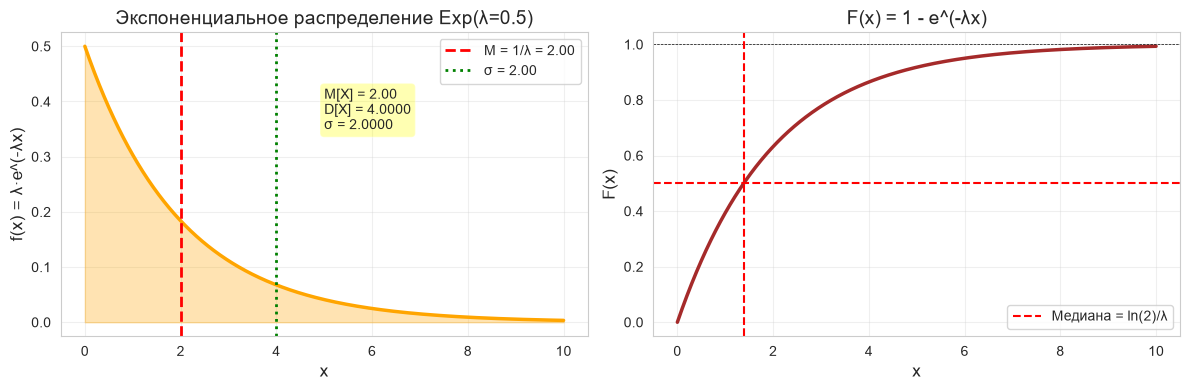

In [11]:
# Экспоненциальное распределение Exp(λ)
# f(x) = λ*e^(-λx), x ≥ 0
# M[X] = 1/λ, D[X] = 1/λ²

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad

lam_exp = 0.5
x_exp = np.linspace(0, 10, 1000)

# ---- АНАЛИТИЧЕСКИЙ РАСЧЁТ ----
M_theory = 1 / lam_exp
D_theory = 1 / lam_exp**2

print(f"Теоретическое M[X] = 1/λ = {M_theory:.4f}")
print(f"Теоретическое D[X] = 1/λ² = {D_theory:.4f}")

# ---- ЧИСЛЕННАЯ ПРОВЕРКА через интегралы ----
def pdf_exp(x):
    return stats.expon.pdf(x, scale=1/lam_exp)

M_num, _ = quad(lambda x: x * pdf_exp(x), 0, 20)
D_num, _ = quad(lambda x: (x - M_num)**2 * pdf_exp(x), 0, 20)
print(f"Численное интегрирование: M[X] = {M_num:.4f}, D[X] = {D_num:.4f}")

# ---- ГРАФИК ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

pdf_exp_vals = stats.expon.pdf(x_exp, scale=1/lam_exp)
cdf_exp_vals = stats.expon.cdf(x_exp, scale=1/lam_exp)

# График 1: Плотность
ax1.plot(x_exp, pdf_exp_vals, color='orange', linewidth=2.5)
ax1.fill_between(x_exp, pdf_exp_vals, alpha=0.3, color='orange')
ax1.axvline(x=M_theory, color='red', linestyle='--', linewidth=2, label=f'M = 1/λ = {M_theory:.2f}')
ax1.axvline(x=M_theory + np.sqrt(D_theory), color='green', linestyle=':', linewidth=2, label=f'σ = {np.sqrt(D_theory):.2f}')
ax1.set_title(f'Экспоненциальное распределение Exp(λ={lam_exp})', fontsize=14)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x) = λ·e^(-λx)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.text(5, 0.35, f'M[X] = {M_theory:.2f}\nD[X] = {D_theory:.4f}\nσ = {np.sqrt(D_theory):.4f}',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3))

# График 2: Функция распределения
ax2.plot(x_exp, cdf_exp_vals, color='brown', linewidth=2.5)
ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Медиана = ln(2)/λ')
ax2.axhline(y=1, color='black', linewidth=0.5, linestyle='--')
ax2.axvline(x=np.log(2)/lam_exp, color='red', linestyle='--', linewidth=1.5)
ax2.set_title('F(x) = 1 - e^(-λx)', fontsize=14)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('F(x)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

<a id="norm-theory"></a>

⬅ [Предыдущая тема](#exp-theory) | ➡ [Следующая тема](#practice) | 📚 [К содержанию](#) | 📝 [Перейти к практическим задачам](#all-tasks)

---
# 🧑‍🎓 Нормальное распределение (Гаусса): $X \sim N(\mu, \sigma^2)$

## 📖 Определение

Самый важный закон в теории вероятностей. Объясняется **Центральной предельной теоремой** (ЦПТ): сумма большого числа независимых случайных величин (с любым распределением) стремится к нормальному.

**Примеры из жизни:**
- Рост и вес людей.
- Ошибки измерений (погрешность приборов).
- IQ и результаты тестов.
- Доходность финансовых инструментов (в приближении).
- Размер деталей при массовом производстве.

---
## 📐 Плотность распределения

$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \cdot \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right), \quad x \in \mathbb{R}$$

**Параметры:**
- $\mu$ — математическое ожидание (среднее, центр распределения).
- $\sigma$ — среднеквадратическое отклонение (разброс). $\sigma^2$ — дисперсия.

**Проверка:** $\int_{-\infty}^{\infty} f(x) dx = 1$ (интеграл Эйлера-Пуассона).

---
## 📈 Функция распределения

$$F(x) = \Phi\left(\frac{x-\mu}{\sigma}\right) = \frac{1}{\sigma\sqrt{2\pi}} \int_{-\infty}^{x} \exp\left(-\frac{(t-\mu)^2}{2\sigma^2}\right) dt$$

$\Phi(z)$ — функция стандартного нормального распределения $N(0, 1)$. Не выражается через элементарные функции, только через таблицы или численно.

---
## 🔢 Числовые характеристики

| Характеристика | Формула |
|----------------|---------|
| Мат. ожидание  | $M[X] = \mu$ |
| Дисперсия      | $D[X] = \sigma^2$ |
| СКО            | $\sigma$ |
| Коэффициент асимметрии | $0$ (симметричное) |
| Коэффициент эксцесса | $0$ (эталонное — для сравнения с другими) |
| Медиана        | $\mu$ |
| Мода           | $\mu$ |

---
## ✨ Ключевые свойства

1. **Симметричность:** плотность симметрична относительно $\mu$.

2. **Правило трех сигм:**
   $$P(|X-\mu| < \sigma) \approx 0.6827$$
   $$P(|X-\mu| < 2\sigma) \approx 0.9545$$
   $$P(|X-\mu| < 3\sigma) \approx 0.9973$$
   **Смысл:** практически все значения (99.73%) лежат в интервале $\mu \pm 3\sigma$.

3. **Линейное преобразование:**
   Если $X \sim N(\mu, \sigma^2)$, то $Y = aX + b \sim N(a\mu + b, a^2\sigma^2)$.
   В частности, стандартизация: $Z = \frac{X-\mu}{\sigma} \sim N(0, 1)$.

4. **Аддитивность:**
   Если $X \sim N(\mu_1, \sigma_1^2)$ и $Y \sim N(\mu_2, \sigma_2^2)$ независимы, то
   $$X + Y \sim N(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2)$$

5. **Связь с другими распределениями:**
   - Если $Z \sim N(0, 1)$, то $Z^2 \sim \chi^2(1)$ (хи-квадрат с 1 степенью свободы).
   - Если $X_1, ..., X_n \sim N(0, 1)$ независимы, то $\sum X_i^2 \sim \chi^2(n)$.
   - Нормальное распределение является предельным для биномиального, Пуассона и многих других.

6. **Максимальная энтропия:**
   Среди всех распределений с заданными $\mu$ и $\sigma^2$ нормальное имеет **максимальную энтропию** (минимальную информацию) — поэтому оно появляется везде, где мы ничего не знаем о распределении, кроме среднего и разброса.

---
## 📊 Стандартное нормальное распределение $N(0, 1)$

- Плотность: $\varphi(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}$.
- Функция распределения: $\Phi(z)$.
- Значения $\Phi(z)$ табулированы во всех учебниках.
- В Python: `stats.norm.cdf(z, 0, 1)`.

---
## 📊 Графики при разных параметрах

- Изменение $\mu$ — сдвигает график влево/вправо.
- Изменение $\sigma$ — меняет "ширину" колокола (чем больше $\sigma$, тем ниже и шире).
- При $\sigma \to 0$ — вырождается в константу $\mu$.
- При $\sigma \to \infty$ — становится почти плоским (равномерным на бесконечном интервале).

---
⬆ [К содержанию](#) | 📝 [Все задачи по нормальному распределению](#all-tasks)
⬅ [Предыдущая тема](#exp-theory) | ➡ [Следующая тема](#practice)

АНАЛИТИЧЕСКИЙ РАСЧЁТ для N(μ, σ²)
μ = 5, σ = 2
M[X] = μ = 5
D[X] = σ² = 4
СКО = σ = 2
Численное интегрирование: M[X] = 5.000000, D[X] = 4.000000


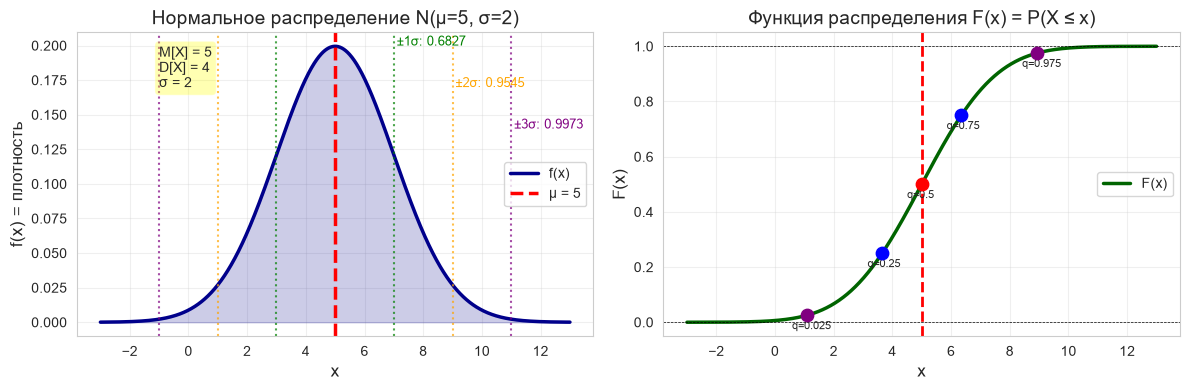


ПРАВИЛО ТРЁХ СИГМ
P(|X-μ| < 1σ) = 0.682689 (68.2689%)
P(|X-μ| < 2σ) = 0.954500 (95.4500%)
P(|X-μ| < 3σ) = 0.997300 (99.7300%)


In [12]:
# Нормальное распределение N(μ, σ²) — ДЕТАЛЬНЫЙ РАЗБОР
# Плотность: f(x) = (1/(σ√(2π))) * exp(-(x-μ)²/(2σ²))
# M[X] = μ, D[X] = σ²

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad

mu_norm, sigma_norm = 5, 2
x_norm = np.linspace(mu_norm - 4*sigma_norm, mu_norm + 4*sigma_norm, 1000)

# ---- АНАЛИТИЧЕСКИЙ РАСЧЁТ ----
print("="*50)
print("АНАЛИТИЧЕСКИЙ РАСЧЁТ для N(μ, σ²)")
print(f"μ = {mu_norm}, σ = {sigma_norm}")
print(f"M[X] = μ = {mu_norm}")
print(f"D[X] = σ² = {sigma_norm**2}")
print(f"СКО = σ = {sigma_norm}")

# ---- ЧИСЛЕННАЯ ПРОВЕРКА через интегралы ----
def pdf_norm_custom(x):
    return stats.norm.pdf(x, mu_norm, sigma_norm)

M_num, _ = quad(lambda x: x * pdf_norm_custom(x), mu_norm - 10*sigma_norm, mu_norm + 10*sigma_norm)
D_num, _ = quad(lambda x: (x - M_num)**2 * pdf_norm_custom(x), mu_norm - 10*sigma_norm, mu_norm + 10*sigma_norm)
print(f"Численное интегрирование: M[X] = {M_num:.6f}, D[X] = {D_num:.6f}")

# ---- ГРАФИК ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

pdf_norm_vals = stats.norm.pdf(x_norm, mu_norm, sigma_norm)
cdf_norm_vals = stats.norm.cdf(x_norm, mu_norm, sigma_norm)

# График 1: Плотность с правилом 3-х сигм
ax1.plot(x_norm, pdf_norm_vals, color='darkblue', linewidth=2.5, label='f(x)')
ax1.fill_between(x_norm, pdf_norm_vals, alpha=0.2, color='darkblue')
ax1.axvline(x=mu_norm, color='red', linewidth=2.5, linestyle='--', label=f'μ = {mu_norm}')

# Интервалы сигм
colors = ['green', 'orange', 'purple']
for i, (color, mult) in enumerate(zip(colors, [1, 2, 3])):
    ax1.axvline(x=mu_norm - mult*sigma_norm, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    ax1.axvline(x=mu_norm + mult*sigma_norm, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    prob = stats.norm.cdf(mult, 0, 1) - stats.norm.cdf(-mult, 0, 1)
    ax1.text(mu_norm + mult*sigma_norm + 0.1, 0.2 - i*0.03, f'±{mult}σ: {prob:.4f}',
             color=color, fontsize=9)

ax1.set_title(f'Нормальное распределение N(μ={mu_norm}, σ={sigma_norm})', fontsize=14)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x) = плотность', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.text(mu_norm - 6, 0.17, f'M[X] = {mu_norm}\nD[X] = {sigma_norm**2}\nσ = {sigma_norm}',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3))

# График 2: Функция распределения с квантилями
ax2.plot(x_norm, cdf_norm_vals, color='darkgreen', linewidth=2.5, label='F(x)')
ax2.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax2.axhline(y=1, color='black', linewidth=0.5, linestyle='--')
ax2.axvline(x=mu_norm, color='red', linestyle='--', linewidth=2)

# Квантили
for q, color in zip([0.025, 0.25, 0.5, 0.75, 0.975], ['purple', 'blue', 'red', 'blue', 'purple']):
    x_q = stats.norm.ppf(q, mu_norm, sigma_norm)
    ax2.scatter(x_q, q, color=color, s=80, zorder=5)
    ax2.annotate(f'q={q}', (x_q, q), xytext=(x_q-0.5, q-0.05), fontsize=8)

ax2.set_title('Функция распределения F(x) = P(X ≤ x)', fontsize=14)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('F(x)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# ---- ДОПОЛНИТЕЛЬНО: ПРОВЕРКА ПРАВИЛА 3-х СИГМ ----
print("\n" + "="*50)
print("ПРАВИЛО ТРЁХ СИГМ")
for k in [1, 2, 3]:
    prob = stats.norm.cdf(k, 0, 1) - stats.norm.cdf(-k, 0, 1)
    print(f"P(|X-μ| < {k}σ) = {prob:.6f} ({prob*100:.4f}%)")

<a id="practice"></a>

⬅ [Предыдущая тема](#norm-theory) | 📚 [К содержанию](#) | 📝 [Перейти к практическим задачам](#all-tasks)

---
# 💻 Практика. Генерация случайных чисел

На практике мы часто генерируем выборку из распределения и сравниваем гистограмму с теоретической плотностью.

Чем больше выборка, тем ближе гистограмма к теоретической кривой.

---
## 📝 Практические задачи

<a id="practice-task-1"></a>
**1.** Сгенерируйте 1000 значений биномиального распределения.

<a id="practice-task-2"></a>
**2.** Постройте гистограмму и сравните с теорией.

---
📖 [Перейти к началу](#practice) | 📝 [Все задачи](#all-tasks)
⬅ [Предыдущая тема](#norm-theory) | 📚 [К содержанию](#)

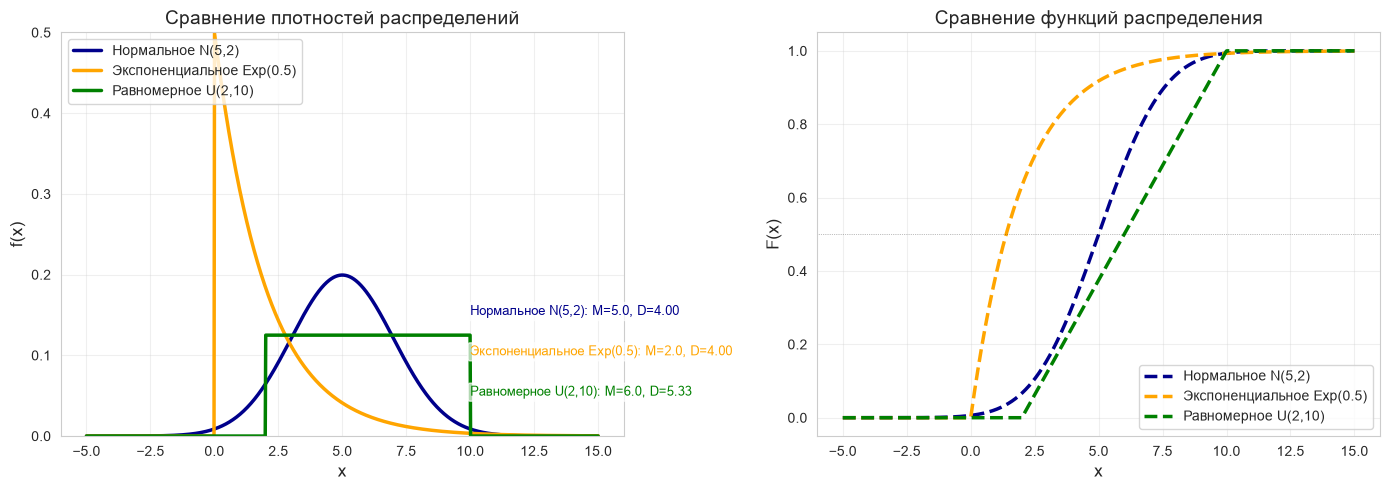

In [14]:
# Сравнение плотностей/рядов распределений на одном графике
# Для каждого распределения показываем: формулу, M[X], D[X]

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x_plot = np.linspace(-5, 15, 1000)

# Параметры для каждого распределения
distributions = [
    {'name': 'Нормальное N(5,2)', 'color': 'darkblue', 'y': stats.norm.pdf(x_plot, 5, 2),
     'M': 5, 'D': 4},
    {'name': 'Экспоненциальное Exp(0.5)', 'color': 'orange',
     'y': stats.expon.pdf(x_plot, scale=2), 'M': 2, 'D': 4},
    {'name': 'Равномерное U(2,10)', 'color': 'green',
     'y': stats.uniform.pdf(x_plot, 2, 8), 'M': 6, 'D': 16/3},
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение плотностей
for d in distributions:
    ax1.plot(x_plot, d['y'], label=d['name'], linewidth=2.5, color=d['color'])
    # Добавляем подпись с M и D
    ax1.text(10, 0.15 - distributions.index(d)*0.05,
             f"{d['name']}: M={d['M']:.1f}, D={d['D']:.2f}",
             color=d['color'], fontsize=9, bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

ax1.set_title('Сравнение плотностей распределений', fontsize=14)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax1.set_ylim(0, 0.5)

# График 2: Функции распределения
for d in distributions:
    if d['name'].startswith('Нормальное'):
        y_cdf = stats.norm.cdf(x_plot, 5, 2)
    elif d['name'].startswith('Экспоненциальное'):
        y_cdf = stats.expon.cdf(x_plot, scale=2)
    else:
        y_cdf = stats.uniform.cdf(x_plot, 2, 8)
    ax2.plot(x_plot, y_cdf, label=d['name'], linewidth=2.5, color=d['color'], linestyle='--')

ax2.axhline(y=0.5, color='black', linewidth=0.5, linestyle=':', alpha=0.5)
ax2.set_title('Сравнение функций распределения', fontsize=14)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('F(x)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()



<a id="all-tasks"></a>
[⬆ К содержанию](#)

---
# 📝 Все практические задачи

## 🎯 Дискретные случайные величины (ДСВ)

<a id="dsv-task-1"></a>
**1.** Составьте закон распределения для честной монеты.

**Формула:** $P(X = k) = C_n^k p^k (1-p)^{n-k}$, где $n=1$, $p=0.5$

💡 [Перейти к решению](#dsv-sol-1)

<a id="dsv-task-2"></a>
**2.** Найдите математическое ожидание для случайной величины, принимающей значения 2,4,6 с вероятностями 0.2,0.5,0.3.

**Формула:** $\mathbb{E}(X) = \sum x_i \cdot p_i$

💡 [Перейти к решению](#dsv-sol-2)

<a id="dsv-task-3"></a>
**3.** Проверьте, что сумма вероятностей равна 1.

**Формула:** $\sum_{i=1}^{n} p_i = 1$

💡 [Перейти к решению](#dsv-sol-3)

## 📈 Функция распределения

<a id="cdf-task-1"></a>
**1.** Постройте функцию распределения для случайной величины, принимающей значения 1,2,3.

**Формула:** $F(x) = P(X \le x) = \sum_{x_i \le x} p_i$

💡 [Перейти к решению](#cdf-sol-1)

<a id="cdf-task-2"></a>
**2.** Найдите F(2).

**Формула:** $F(2) = P(X \le 2)$

💡 [Перейти к решению](#cdf-sol-2)

## 🎲 Биномиальное распределение

<a id="binom-task-1"></a>
**1.** Найдите P(X=3) при n=8, p=0.4.

**Формула:** $P(X = k) = C_n^k p^k (1-p)^{n-k}$

💡 [Перейти к решению](#binom-sol-1)

<a id="binom-task-2"></a>
**2.** Найдите P(X≤2).

**Формула:** $P(X \le 2) = \sum_{k=0}^{2} C_n^k p^k (1-p)^{n-k}$

💡 [Перейти к решению](#binom-sol-2)

<a id="binom-task-3"></a>
**3.** Смоделируйте 10000 экспериментов и сравните.

**Формула:** `np.random.binomial(n, p, size=10000)`

💡 [Перейти к решению](#binom-sol-3)

## 🎯 Геометрическое распределение

<a id="geom-task-1"></a>
**1.** Найдите вероятность первого успеха на 4-й попытке при p=0.3.

**Формула:** $P(X = k) = (1-p)^{k-1} \cdot p$

💡 [Перейти к решению](#geom-sol-1)

<a id="geom-task-2"></a>
**2.** Найдите матожидание.

**Формула:** $\mathbb{E}(X) = \frac{1}{p}$

💡 [Перейти к решению](#geom-sol-2)

## 📞 Распределение Пуассона

<a id="poisson-task-1"></a>
**1.** Вычислите P(X=2) при λ=3.

**Формула:** $P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$

💡 [Перейти к решению](#poisson-sol-1)

<a id="poisson-task-2"></a>
**2.** Найдите вероятность X≤3.

**Формула:** $P(X \le 3) = \sum_{k=0}^{3} \frac{\lambda^k e^{-\lambda}}{k!}$

💡 [Перейти к решению](#poisson-sol-2)

## 📏 Непрерывное равномерное распределение

<a id="unif-task-1"></a>
**1.** Для U(2,8) найдите M[X] и D[X].

**Формулы:** $\mathbb{E}(X) = \frac{a+b}{2}$, $\mathbb{D}(X) = \frac{(b-a)^2}{12}$

💡 [Перейти к решению](#unif-sol-1)

<a id="unif-task-2"></a>
**2.** Найдите P(3≤X≤5).

**Формула:** $P(a \le X \le b) = \frac{b-a}{B-A}$

💡 [Перейти к решению](#unif-sol-2)

## ⏳ Экспоненциальное распределение

<a id="exp-task-1"></a>
**1.** Для λ=0.5 найдите вероятность X>2.

**Формула:** $P(X > t) = e^{-\lambda t}$

💡 [Перейти к решению](#exp-sol-1)

<a id="exp-task-2"></a>
**2.** Найдите M[X].

**Формула:** $\mathbb{E}(X) = \frac{1}{\lambda}$

💡 [Перейти к решению](#exp-sol-2)

## 🧑‍🎓 Нормальное распределение

<a id="norm-task-1"></a>
**1.** Для N(0,1) найдите P(-1<X<1).

**Формула:** $P(-1 < Z < 1) = \Phi(1) - \Phi(-1)$

💡 [Перейти к решению](#norm-sol-1)

<a id="norm-task-2"></a>
**2.** Как изменится график при увеличении σ?

**Формула:** $f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$

💡 [Перейти к решению](#norm-sol-2)

## 💻 Практика. Генерация случайных чисел

<a id="practice-task-1"></a>
**1.** Сгенерируйте 1000 значений биномиального распределения.

**Формула:** `np.random.binomial(n, p, size=1000)`

💡 [Перейти к решению](#practice-sol-1)

<a id="practice-task-2"></a>
**2.** Постройте гистограмму и сравните с теорией.

**Формула:** `plt.hist(data, bins, density=True)`

💡 [Перейти к решению](#practice-sol-2)

---
📖 [Перейти к теории](#) | 💡 [Перейти ко всем решениям](#all-solutions)
📚 [К содержанию](#)

<a id="dsv-solutions"></a>
[⬆ К содержанию](#)

---
## 🎯 Дискретные случайные величины (ДСВ)

<a id="dsv-sol-1"></a>
**Решение 1.** Закон распределения для честной монеты:

| X | 0 | 1 |
|---|---|---|
| P | 0.5 | 0.5 |

<a id="dsv-sol-2"></a>
**Решение 2.** M[X] = 2·0.2 + 4·0.5 + 6·0.3 = 0.4 + 2.0 + 1.8 = 4.2

<a id="dsv-sol-3"></a>
**Решение 3.** 0.2 + 0.5 + 0.3 = 1.0 ✓

---
📝 [Вернуться к задачам](#dsv-task-1) | 📖 [Перейти к теории](#dsv-theory)
📚 [К содержанию](#)

<a id="cdf-solutions"></a>
[⬆ К содержанию](#)

---
## 📈 Функция распределения

<a id="cdf-sol-1"></a>
**Решение 1.** F(x) = 0 при x<1; 1/3 при 1≤x<2; 2/3 при 2≤x<3; 1 при x≥3.

<a id="cdf-sol-2"></a>
**Решение 2.** F(2) = 2/3.

---
📝 [Вернуться к задачам](#cdf-task-1) | 📖 [Перейти к теории](#cdf-theory)
📚 [К содержанию](#)

<a id="binom-solutions"></a>
[⬆ К содержанию](#)

---
## 🎲 Биномиальное распределение

<a id="binom-sol-1"></a>
**Решение 1.** P(X=3) = C(8,3)·0.4³·0.6⁵ ≈ 56·0.064·0.07776 ≈ 0.279

<a id="binom-sol-2"></a>
**Решение 2.** P(X≤2) = P(0)+P(1)+P(2) ≈ 0.0168 + 0.0896 + 0.2090 ≈ 0.3154

<a id="binom-sol-3"></a>
**Решение 3.** Используйте `np.random.binomial(n, p, size=10000)` и постройте гистограмму.

---
📝 [Вернуться к задачам](#binom-task-1) | 📖 [Перейти к теории](#binom-theory)
📚 [К содержанию](#)

<a id="geom-solutions"></a>
[⬆ К содержанию](#)

---
## 🎯 Геометрическое распределение

<a id="geom-sol-1"></a>
**Решение 1.** P(X=4) = (1-0.3)³·0.3 = 0.7³·0.3 = 0.343·0.3 = 0.1029

<a id="geom-sol-2"></a>
**Решение 2.** M[X] = 1/p = 1/0.3 ≈ 3.33

---
📝 [Вернуться к задачам](#geom-task-1) | 📖 [Перейти к теории](#geom-theory)
📚 [К содержанию](#)

<a id="poisson-solutions"></a>
[⬆ К содержанию](#)

---
## 📞 Распределение Пуассона

<a id="poisson-sol-1"></a>
**Решение 1.** P(X=2) = (3²·e⁻³)/2! = 9·0.0498/2 ≈ 0.224

<a id="poisson-sol-2"></a>
**Решение 2.** P(X≤3) = e⁻³·(1 + 3 + 9/2 + 27/6) ≈ 0.0498·(1 + 3 + 4.5 + 4.5) = 0.0498·13 = 0.647

---
📝 [Вернуться к задачам](#poisson-task-1) | 📖 [Перейти к теории](#poisson-theory)
📚 [К содержанию](#)

<a id="cont-solutions"></a>
[⬆ К содержанию](#)

---
## 📏 Непрерывное равномерное распределение

<a id="unif-sol-1"></a>
**Решение 1.** M[X] = (2+8)/2 = 5; D[X] = (8-2)²/12 = 36/12 = 3

<a id="unif-sol-2"></a>
**Решение 2.** P(3≤X≤5) = (5-3)/(8-2) = 2/6 = 1/3 ≈ 0.333

---
## ⏳ Экспоненциальное распределение

<a id="exp-sol-1"></a>
**Решение 1.** P(X>2) = e^(-0.5·2) = e⁻¹ ≈ 0.368

<a id="exp-sol-2"></a>
**Решение 2.** M[X] = 1/λ = 1/0.5 = 2

---
## 🧑‍🎓 Нормальное распределение

<a id="norm-sol-1"></a>
**Решение 1.** P(-1<X<1) = Φ(1) - Φ(-1) ≈ 0.8413 - 0.1587 = 0.6826

<a id="norm-sol-2"></a>
**Решение 2.** При увеличении σ график становится более пологим и широким, максимум плотности уменьшается.

---
📝 [Вернуться к задачам](#unif-task-1) | 📖 [Перейти к теории](#unif-theory)
📚 [К содержанию](#)

<a id="all-tasks"></a>
[⬆ К содержанию](#)

---
# 📝 Практические задачи

> 💡 **Совет:** Для каждой задачи записывайте, какое распределение используется и почему.

---

## 🎯 Задача 1. Дискретная случайная величина

Случайная величина $X$ задана рядом распределения:

| $X$ | 0 | 1 | 2 | 3 |
|:---:|:---:|:---:|:---:|:---:|
| $P(X=x)$ | 0.1 | 0.3 | 0.4 | 0.2 |

**Найдите:**

1. Вероятность события $X \ge 2$;
2. Математическое ожидание $\mathbb{E}(X)$;
3. Дисперсию $\mathbb{D}(X)$.

---
📖 [Перейти к теории ДСВ](#dsv-theory) | 💡 [Перейти к решению](#dsv-sol-1)
⬅ [Предыдущая задача](#) | ➡ [Следующая задача](#cdf-task-1) | 📚 [К содержанию](#)

---

## 📈 Задача 2. Функция распределения

Дана функция распределения случайной величины:

$$F(x)= \begin{cases} 0, & x < 0,\\ 0.2, & 0 \le x < 1,\\ 0.6, & 1 \le x < 2,\\ 0.9, & 2 \le x < 3,\\ 1, & x \ge 3. \end{cases}$$

**Найдите:**

1. $P(X = 1)$;
2. $P(1 < X \le 3)$;
3. $P(X < 2)$.

---
📖 [Перейти к теории функции распределения](#cdf-theory) | 💡 [Перейти к решению](#cdf-sol-1)
⬅ [Предыдущая задача](#dsv-task-1) | ➡ [Следующая задача](#binom-task-1) | 📚 [К содержанию](#)

---

## 🪙 Задача 3. Биномиальное распределение

Монету подбрасывают **10 раз**. Вероятность выпадения орла равна $p = 0.6$.

**Найдите:**

1. вероятность появления **ровно 6** орлов;
2. вероятность появления **не более 3** орлов;
3. математическое ожидание и дисперсию числа орлов.

---
📖 [Перейти к теории биномиального распределения](#binom-theory) | 💡 [Перейти к решению](#binom-sol-1)
⬅ [Предыдущая задача](#cdf-task-1) | ➡ [Следующая задача](#geom-task-1) | 📚 [К содержанию](#)

---

## 🎯 Задача 4. Геометрическое распределение

Вероятность попадания в цель **одним выстрелом** равна $p = 0.25$. Стрельба продолжается до **первого попадания**.

**Найдите:**

1. вероятность попасть впервые с **четвёртого** выстрела;
2. вероятность попасть **не позднее третьего** выстрела;
3. математическое ожидание числа выстрелов.

---
📖 [Перейти к теории геометрического распределения](#geom-theory) | 💡 [Перейти к решению](#geom-sol-1)
⬅ [Предыдущая задача](#binom-task-1) | ➡ [Следующая задача](#poisson-task-1) | 📚 [К содержанию](#)

---

## 📞 Задача 5. Распределение Пуассона

В среднем в службу поддержки поступает **4 обращения в час**. Считаем, что число обращений распределено по закону Пуассона.

**Найдите** вероятность того, что за следующий час поступит:

1. ровно **2** обращения;
2. **не более одного** обращения;
3. **более пяти** обращений.

---
📖 [Перейти к теории распределения Пуассона](#poisson-theory) | 💡 [Перейти к решению](#poisson-sol-1)
⬅ [Предыдущая задача](#geom-task-1) | ➡ [Следующая задача](#unif-task-1) | 📚 [К содержанию](#)

---

## 📏 Задача 6. Непрерывное равномерное распределение

Случайная величина $X$ равномерно распределена на отрезке $[2; 8]$.

**Найдите:**

1. вероятность того, что $X \in [3; 5]$;
2. математическое ожидание $\mathbb{E}(X)$;
3. дисперсию $\mathbb{D}(X)$.

---
📖 [Перейти к теории равномерного распределения](#unif-theory) | 💡 [Перейти к решению](#unif-sol-1)
⬅ [Предыдущая задача](#poisson-task-1) | ➡ [Следующая задача](#exp-task-1) | 📚 [К содержанию](#)

---

## ⏳ Задача 7. Экспоненциальное распределение

Среднее время работы устройства до отказа равно **5 часов**. Предполагается экспоненциальное распределение времени безотказной работы.

**Найдите:**

1. вероятность того, что устройство проработает **более 6** часов;
2. вероятность отказа в течение **первых двух** часов;
3. интенсивность отказов $\lambda$.

---
📖 [Перейти к теории экспоненциального распределения](#exp-theory) | 💡 [Перейти к решению](#exp-sol-1)
⬅ [Предыдущая задача](#unif-task-1) | ➡ [Следующая задача](#norm-task-1) | 📚 [К содержанию](#)

---

## 🧑‍🎓 Задача 8. Нормальное распределение

Рост студентов имеет **нормальное распределение** с параметрами:

$$\mu = 175 \text{ см}, \qquad \sigma = 8 \text{ см}.$$

**Найдите:**

1. вероятность того, что рост студента **меньше 183** см;
2. вероятность того, что рост находится **между 167 и 183** см;
3. интервал, содержащий примерно **95%** наблючений (правило $2\sigma$).

---
📖 [Перейти к теории нормального распределения](#norm-theory) | 💡 [Перейти к решению](#norm-sol-1)
⬅ [Предыдущая задача](#exp-task-1) | ➡ [Следующая задача](#practice-task-1) | 📚 [К содержанию](#)

---

## 🧠 Задача 9. Сравнение распределений

Для каждого случая определите, **какое распределение** наиболее подходит:

| № | Ситуация | Распределение |
|:---:|:---|:---:|
| 1 | число автомобилей, проезжающих через перекрёсток за минуту | ? |
| 2 | число бросков до первого успеха | ? |
| 3 | количество успехов в 20 независимых испытаниях | ? |
| 4 | случайное время ожидания между двумя событиями | ? |
| 5 | случайный момент прихода автобуса, если он может прийти в любой момент в течение 10 минут с одинаковой вероятностью | ? |

**Обоснуйте** свой выбор для каждого пункта.

---
📖 [Перейти к теории](#) | 💡 [Перейти к решению](#cont-sol-1)
⬅ [Предыдущая задача](#norm-task-1) | ➡ [Следующая задача](#) | 📚 [К содержанию](#)

---

## 💻 Задача 10. Генерация случайных чисел

**1.** Сгенерируйте 1000 значений биномиального распределения с параметрами n=10, p=0.5.

**2.** Постройте гистограмму и сравните с теоретической плотностью.

---
📖 [Перейти к практике](#practice) | 💡 [Перейти к решению](#practice-sol-1)
⬅ [Предыдущая задача](#norm-task-1) | 📚 [К содержанию](#)

📝 [Все задачи](#all-tasks) | 💡 [Все решения](#all-solutions)

<a id="all-solutions"></a>
[⬆ К содержанию](#)

---
# ✅ Решения практических задач

> 📝 **Примечание:** В решениях используются стандартные обозначения: $\mathbb{E}(X)$ — математическое ожидание, $\mathbb{D}(X)$ — дисперсия.

---

## 🎯 Задача 1. Дискретная случайная величина

**Ряд распределения:** $X = \{0, 1, 2, 3\}$, $P = \{0.1, 0.3, 0.4, 0.2\}$

<a id="dsv-sol-1"></a>
### 1. Вероятность $P(X \ge 2)$

$$P(X \ge 2) = P(X=2) + P(X=3) = 0.4 + 0.2 = 0.6$$

**Ответ:** $0.6$

### 2. Математическое ожидание $\mathbb{E}(X)$

$$\mathbb{E}(X) = 0 \cdot 0.1 + 1 \cdot 0.3 + 2 \cdot 0.4 + 3 \cdot 0.2 = 1.7$$

**Ответ:** $\mathbb{E}(X) = 1.7$

### 3. Дисперсия $\mathbb{D}(X)$

$$\mathbb{E}(X^2) = 0^2 \cdot 0.1 + 1^2 \cdot 0.3 + 2^2 \cdot 0.4 + 3^2 \cdot 0.2 = 3.7$$

$$\mathbb{D}(X) = \mathbb{E}(X^2) - [\mathbb{E}(X)]^2 = 3.7 - 1.7^2 = 0.81$$

**Ответ:** $\mathbb{D}(X) = 0.81$

---
📝 [Вернуться к задаче](#dsv-task-1) | 📖 [Перейти к теории](#dsv-theory)
⬅ [Предыдущее решение](#) | ➡ [Следующее решение](#cdf-sol-1) | 📚 [К содержанию](#)

---

## 📈 Задача 2. Функция распределения

<a id="cdf-sol-1"></a>
### 1. Вероятность $P(X = 1)$

$$P(X = 1) = F(1) - F(1-0) = 0.6 - 0.2 = 0.4$$

**Ответ:** $0.4$

### 2. Вероятность $P(1 < X \le 3)$

$$P(1 < X \le 3) = F(3) - F(1) = 1 - 0.6 = 0.4$$

**Ответ:** $0.4$

### 3. Вероятность $P(X < 2)$

$$P(X < 2) = F(2-0) = 0.6$$

**Ответ:** $0.6$

---
📝 [Вернуться к задаче](#cdf-task-1) | 📖 [Перейти к теории](#cdf-theory)
⬅ [Предыдущее решение](#dsv-sol-1) | ➡ [Следующее решение](#binom-sol-1) | 📚 [К содержанию](#)

---

## 🪙 Задача 3. Биномиальное распределение

<a id="binom-sol-1"></a>
**Параметры:** $n = 10$, $p = 0.6$, $q = 0.4$

**Формула:** $\displaystyle P(X = k) = C_n^k p^k q^{n-k}$

### 1. Вероятность $P(X = 6)$

$$P(X = 6) = C_{10}^6 \cdot 0.6^6 \cdot 0.4^4 \approx 210 \cdot 0.046656 \cdot 0.0256 \approx 0.251$$

**Ответ:** $\approx 0.251$

### 2. Вероятность $P(X \le 3)$

$$P(X \le 3) = \sum_{k=0}^{3} C_{10}^k \cdot 0.6^k \cdot 0.4^{10-k} \approx 0.055$$

**Ответ:** $\approx 0.055$

### 3. Математическое ожидание и дисперсия

$$\mathbb{E}(X) = np = 10 \cdot 0.6 = 6$$

$$\mathbb{D}(X) = np(1-p) = 10 \cdot 0.6 \cdot 0.4 = 2.4$$

**Ответ:** $\mathbb{E}(X) = 6$, $\mathbb{D}(X) = 2.4$

---
📝 [Вернуться к задаче](#binom-task-1) | 📖 [Перейти к теории](#binom-theory)
⬅ [Предыдущее решение](#cdf-sol-1) | ➡ [Следующее решение](#geom-sol-1) | 📚 [К содержанию](#)

---

## 🎯 Задача 4. Геометрическое распределение

<a id="geom-sol-1"></a>
**Параметры:** $p = 0.25$, $q = 0.75$

**Формула:** $P(X = k) = q^{k-1} \cdot p$

### 1. Вероятность $P(X = 4)$

$$P(X = 4) = 0.75^{3} \cdot 0.25 \approx 0.421875 \cdot 0.25 \approx 0.105$$

**Ответ:** $\approx 0.105$

### 2. Вероятность $P(X \le 3)$

$$P(X \le 3) = 1 - P(X > 3) = 1 - q^3 = 1 - 0.75^3 = 1 - 0.421875 \approx 0.578$$

**Ответ:** $\approx 0.578$

### 3. Математическое ожидание

$$\mathbb{E}(X) = \frac{1}{p} = \frac{1}{0.25} = 4$$

**Ответ:** $\mathbb{E}(X) = 4$

---
📝 [Вернуться к задаче](#geom-task-1) | 📖 [Перейти к теории](#geom-theory)
⬅ [Предыдущее решение](#binom-sol-1) | ➡ [Следующее решение](#poisson-sol-1) | 📚 [К содержанию](#)

---

## 📞 Задача 5. Распределение Пуассона

<a id="poisson-sol-1"></a>
**Параметр:** $\lambda = 4$ (среднее число обращений в час)

**Формула:** $\displaystyle P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$

### 1. Вероятность $P(X = 2)$

$$P(X = 2) = \frac{4^2 \cdot e^{-4}}{2!} = \frac{16 \cdot e^{-4}}{2} \approx 0.147$$

**Ответ:** $\approx 0.147$

### 2. Вероятность $P(X \le 1)$

$$P(X \le 1) = P(X=0) + P(X=1) = e^{-4} + 4e^{-4} = 5e^{-4} \approx 0.092$$

**Ответ:** $\approx 0.092$

### 3. Вероятность $P(X > 5)$

$$P(X > 5) = 1 - \sum_{k=0}^{5} \frac{4^k e^{-4}}{k!} \approx 1 - 0.785 \approx 0.215$$

**Ответ:** $\approx 0.215$

---
📝 [Вернуться к задаче](#poisson-task-1) | 📖 [Перейти к теории](#poisson-theory)
⬅ [Предыдущее решение](#geom-sol-1) | ➡ [Следующее решение](#unif-sol-1) | 📚 [К содержанию](#)

---

## 📏 Задача 6. Непрерывное равномерное распределение

<a id="unif-sol-1"></a>
**Параметры:** $a = 2$, $b = 8$

**Плотность:** $\displaystyle f(x) = \frac{1}{b-a} = \frac{1}{6}$ при $x \in [2; 8]$

### 1. Вероятность $P(3 \le X \le 5)$

$$P(3 \le X \le 5) = \frac{5 - 3}{8 - 2} = \frac{2}{6} = \frac{1}{3}$$

**Ответ:** $\frac{1}{3} \approx 0.333$

### 2. Математическое ожидание

$$\mathbb{E}(X) = \frac{a + b}{2} = \frac{2 + 8}{2} = 5$$

**Ответ:** $\mathbb{E}(X) = 5$

### 3. Дисперсия

$$\mathbb{D}(X) = \frac{(b - a)^2}{12} = \frac{(8 - 2)^2}{12} = \frac{36}{12} = 3$$

**Ответ:** $\mathbb{D}(X) = 3$

---
📝 [Вернуться к задаче](#unif-task-1) | 📖 [Перейти к теории](#unif-theory)
⬅ [Предыдущее решение](#poisson-sol-1) | ➡ [Следующее решение](#exp-sol-1) | 📚 [К содержанию](#)

---

## ⏳ Задача 7. Экспоненциальное распределение

<a id="exp-sol-1"></a>
**Дано:** $\mathbb{E}(X) = 5$ часов

**Интенсивность отказов:** $\displaystyle \lambda = \frac{1}{\mathbb{E}(X)} = \frac{1}{5} = 0.2$

**Функция надёжности:** $P(X > t) = e^{-\lambda t}$

**Функция распределения:** $P(X \le t) = 1 - e^{-\lambda t}$

### 1. Вероятность $P(X > 6)$

$$P(X > 6) = e^{-0.2 \cdot 6} = e^{-1.2} \approx 0.301$$

**Ответ:** $\approx 0.301$

### 2. Вероятность $P(X \le 2)$

$$P(X \le 2) = 1 - e^{-0.2 \cdot 2} = 1 - e^{-0.4} \approx 1 - 0.670 = 0.330$$

**Ответ:** $\approx 0.330$

### 3. Интенсивность отказов

$$\lambda = \frac{1}{5} = 0.2 \text{ (отказов в час)}$$

**Ответ:** $\lambda = 0.2$

---
📝 [Вернуться к задаче](#exp-task-1) | 📖 [Перейти к теории](#exp-theory)
⬅ [Предыдущее решение](#unif-sol-1) | ➡ [Следующее решение](#norm-sol-1) | 📚 [К содержанию](#)

---

## 🧑‍🎓 Задача 8. Нормальное распределение

<a id="norm-sol-1"></a>
**Параметры:** $\mu = 175$, $\sigma = 8$

**Стандартизация:** $\displaystyle Z = \frac{X - \mu}{\sigma}$

### 1. Вероятность $P(X < 183)$

$$Z = \frac{183 - 175}{8} = \frac{8}{8} = 1$$

$$P(X < 183) = P(Z < 1) \approx 0.841$$

**Ответ:** $\approx 0.841$

### 2. Вероятность $P(167 < X < 183)$

$$Z_1 = \frac{167 - 175}{8} = -1, \qquad Z_2 = \frac{183 - 175}{8} = 1$$

$$P(167 < X < 183) = P(-1 < Z < 1) \approx 0.683$$

**Ответ:** $\approx 0.683$

### 3. Интервал для 95% наблюдений

По **правилу $2\sigma$**:

$$\mu \pm 2\sigma = 175 \pm 2 \cdot 8 = [159; 191]$$

**Ответ:** примерно $95\%$ значений лежат в интервале $[159; 191]$ см

---
📝 [Вернуться к задаче](#norm-task-1) | 📖 [Перейти к теории](#norm-theory)
⬅ [Предыдущее решение](#exp-sol-1) | ➡ [Следующее решение](#cont-sol-1) | 📚 [К содержанию](#)

---

## 🧠 Задача 9. Сравнение распределений

<a id="cont-sol-1"></a>
| № | Ситуация | Распределение | Обоснование |
|:---:|:---|:---:|:---|
| 1 | число автомобилей за минуту | **Пуассона** | Считаем редкие события на фиксированном интервале времени |
| 2 | число бросков до первого успеха | **Геометрическое** | Ждём первый "успех" в последовательности независимых испытаний |
| 3 | количество успехов в 20 испытаниях | **Биномиальное** | Фиксированное число испытаний ($n=20$) с постоянной вероятностью успеха |
| 4 | время между двумя событиями | **Экспоненциальное** | Моделирует время ожидания между событиями в пуассоновском потоке |
| 5 | момент прихода автобуса | **Равномерное** | Все моменты времени равновозможны на заданном интервале |

---
📝 [Вернуться к задаче](#cont-task-1) | 📖 [Перейти к теории](#)
⬅ [Предыдущее решение](#norm-sol-1) | ➡ [Следующее решение](#practice-sol-1) | 📚 [К содержанию](#)

---

## 💻 Задача 10. Генерация случайных чисел

<a id="practice-sol-1"></a>
**Решение.**

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Генерация 1000 значений биномиального распределения
n, p = 10, 0.5
sample = np.random.binomial(n, p, size=1000)

# Теоретические вероятности
k = np.arange(0, n+1)
theoretical = stats.binom.pmf(k, n, p)

# Гистограмма и сравнение
plt.hist(sample, bins=np.arange(-0.5, n+1.5, 1), density=True, alpha=0.7, label='Выборка')
plt.plot(k, theoretical, 'ro-', label='Теория')
plt.xlabel('k')
plt.ylabel('Частота / P(X=k)')
plt.legend()
plt.title(f'Биномиальное распределение Bin(n={n}, p={p})')
plt.show()